<hr style="height:2.5px;">

#  What is Data Preprocessing?
    Data preprocessing is the process of transforming raw data into a clean and suitable format before feeding it into machine learning or analysis.

    Raw data is often:
        incomplete
        inconsistent
        noisy
        unscaled
        categorical
        Without preprocessing → model performance drops badly.

   Goals of Data Preprocessing

        Improve data quality
        Handle missing values
        Remove noise/outliers
        Convert categorical data
        Normalize/scale features
        Make data model-ready

   Major Steps in Data Preprocessing

        Handling Missing Values
        Handling Duplicates
        Handling Outliers
        Handling Noisy Data
        Encoding Categorical Variables
        Feature Scaling
        Feature Transformation
        Data Reduction

In [31]:
# Example Dataset (We Will Use This)
import pandas as pd
import numpy as np

data = {
    "Age": [25, np.nan, 35, 40, 29, 120, 30, np.nan],
    "Salary": [50000, 60000, np.nan, 80000, 52000, 1000000, 58000, 50000],
    "City": ["Delhi", "Mumbai", "Delhi", "Chennai", np.nan, "Delhi", "Mumbai", "Chandigarh"],
    "Purchased": ["Yes", "No", "Yes", "No", "Yes", "No", "Yes","No"]
}

df = pd.DataFrame(data)
display(df)

,Age,Salary,City,Purchased
0,25.0,50000.0,Delhi,Yes
1,NaN,60000.0,Mumbai,No
2,35.0,NaN,Delhi,Yes
3,40.0,80000.0,Chennai,No
4,29.0,52000.0,NaN,Yes
5,120.0,1000000.0,Delhi,No
6,30.0,58000.0,Mumbai,Yes
7,NaN,50000.0,Chandigarh,No


<hr style="height:2.5px;">

# 1. Handling Missing Values(visuzation or pandas)
    Problem
        Missing data occurs when no value is stored.
        
        Types
            MCAR (Missing Completely at Random)
            MAR (Missing at Random)
            MNAR (Missing Not at Random)
    

In [2]:
import matplotlib.pyplot as plt

In [5]:
df.isnull().sum()

Age          2
Salary       1
City         1
Purchased    0
dtype: int64

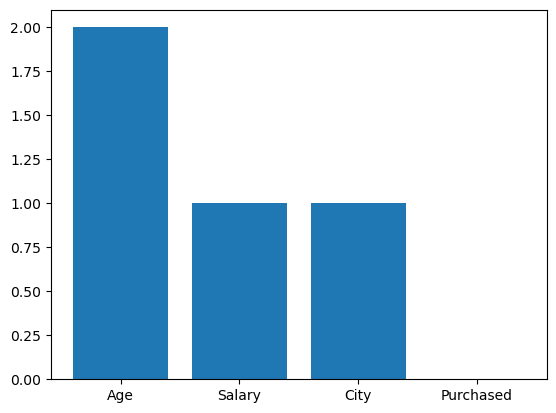

In [6]:
plt.bar(df.columns, df.isnull().sum())
plt.show()

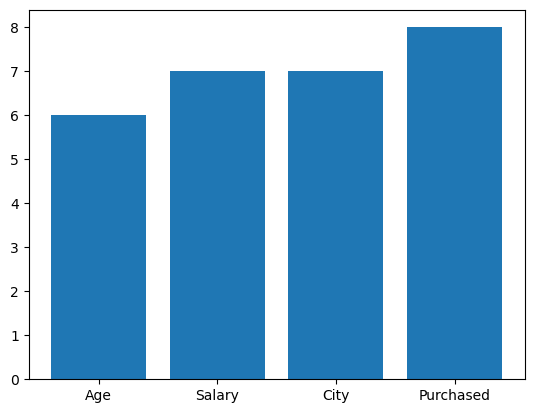

In [7]:
plt.bar(df.columns, df.notnull().sum())
plt.show()

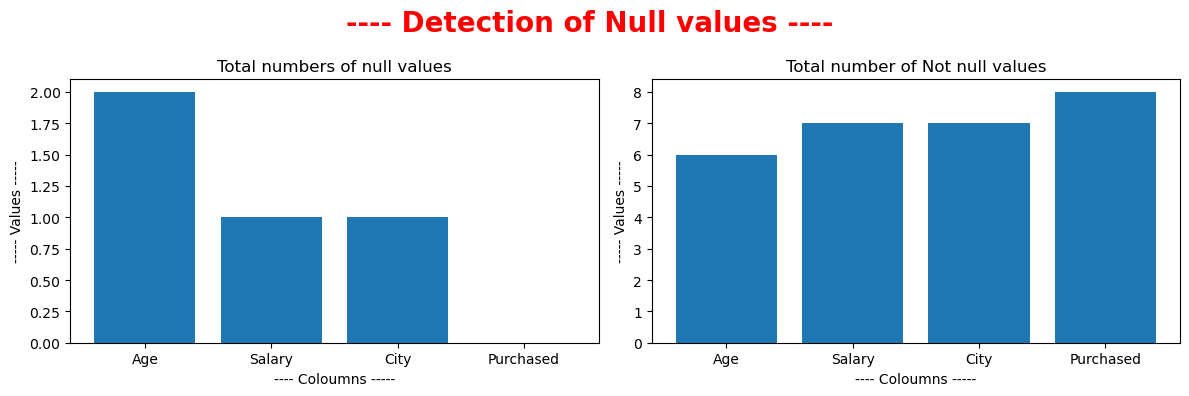

In [8]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.bar(df.columns, df.isnull().sum())
plt.title("Total numbers of null values")
plt.xlabel("---- Coloumns -----")
plt.ylabel("----- Values -----")

plt.subplot(1,2, 2)
plt.bar(df.columns, df.notnull().sum())
plt.title("Total number of Not null values")
plt.xlabel("---- Coloumns -----")
plt.ylabel("----- Values -----")

plt.suptitle("---- Detection of Null values ---- ", size = 20, color = 'r', weight = 'bold')
plt.tight_layout()
plt.show()

In [9]:
df.isnull().sum()

Age          2
Salary       1
City         1
Purchased    0
dtype: int64

In [14]:
(df['Salary'].isnull().sum() / len(df['Salary']) ) * 100

np.float64(12.5)

In [15]:
df['Age'].isnull().sum() / len(df['Age']) * 100

np.float64(25.0)

In [16]:
df.columns

Index(['Age', 'Salary', 'City', 'Purchased'], dtype='object')

In [17]:
col = list(df.columns)
c_n_l = []
c_per = []
c_not_l = []
c_not_per = []
for i in col:
    c_n = df[i].isnull().sum()
    c_n_l.append(c_n)
    c_not = df[i].notnull().sum()
    c_not_l.append(c_not)
    per = (df[i].isnull().sum() / len(df[i])) * 100
    c_per.append(per)
    not_per = (df[i].notnull().sum() / len(df[i])) * 100
    c_not_per.append(not_per)
    print(f"{i}\t{c_n}\t{per}%\t{c_not}\t{not_per}%")

Age	2	25.0%	6	75.0%
Salary	1	12.5%	7	87.5%
City	1	12.5%	7	87.5%
Purchased	0	0.0%	8	100.0%


In [18]:
dic = {
    "columns_name " : col,
    "count_null" : c_n_l,
    "%age_null" : c_per,
    "count_not_null" : c_not_l,
    "%age_not" : c_not_per
}
null_df = pd.DataFrame(dic)
null_df

,columns_name,count_null,%age_null,count_not_null,%age_not
0,Age,2,25.0,6,75.0
1,Salary,1,12.5,7,87.5
2,City,1,12.5,7,87.5
3,Purchased,0,0.0,8,100.0


<hr style="height:2.5px;">

# Techniques to Handle Missing Values (Remove[<5%], Replace)
     Method 1: Mean Imputation
            Xnew = ∑Xi / n

    Replace missing value with column mean.

In [21]:
print(df['Age'].mean())
print(round(df['Salary'].mean()))

46.5
192857


In [23]:
# Sentive toward outliers
df["Age_fill_mean"] = df["Age"].fillna(df["Age"].mean())
df["Salary_fill_mean"] = df["Salary"].fillna(round(df["Salary"].mean()))
df

,Age,Salary,City,Purchased,Age_fill_mean,Salary_fill_mean
0,25.0,50000.0,Delhi,Yes,25.0,50000.0
1,NaN,60000.0,Mumbai,No,46.5,60000.0
2,35.0,NaN,Delhi,Yes,35.0,192857.0
3,40.0,80000.0,Chennai,No,40.0,80000.0
4,29.0,52000.0,NaN,Yes,29.0,52000.0
5,120.0,1000000.0,Delhi,No,120.0,1000000.0
6,30.0,58000.0,Mumbai,Yes,30.0,58000.0
7,NaN,50000.0,Chandigarh,No,46.5,50000.0


# When to Use
    Data is normally distributed
    Few missing values

# Impact
    Reduces variance
    Can introduce bias

<hr style="height:2.5px;">

# Method 2: Median Imputation
    𝑋𝑛𝑒𝑤=𝑀𝑒𝑑𝑖𝑎𝑛(𝑋)

# Best For
    Skewed data
    Outliers present

In [24]:
df["Age_fill_median"] = df["Age"].fillna(df["Age"].median())
df["Salary_fill_median"] = df["Salary"].fillna(round(df["Salary"].median()))
df

,Age,Salary,City,Purchased,Age_fill_mean,Salary_fill_mean,Age_fill_median,Salary_fill_median
0,25.0,50000.0,Delhi,Yes,25.0,50000.0,25.0,50000.0
1,NaN,60000.0,Mumbai,No,46.5,60000.0,32.5,60000.0
2,35.0,NaN,Delhi,Yes,35.0,192857.0,35.0,58000.0
3,40.0,80000.0,Chennai,No,40.0,80000.0,40.0,80000.0
4,29.0,52000.0,NaN,Yes,29.0,52000.0,29.0,52000.0
5,120.0,1000000.0,Delhi,No,120.0,1000000.0,120.0,1000000.0
6,30.0,58000.0,Mumbai,Yes,30.0,58000.0,30.0,58000.0
7,NaN,50000.0,Chandigarh,No,46.5,50000.0,32.5,50000.0


<hr style="height:2.5px;">

# Method 3: Mode Imputation (Categorical)
    Xnew=Mode(X)

In [26]:
df['City'].value_counts()

City
Delhi         3
Mumbai        2
Chennai       1
Chandigarh    1
Name: count, dtype: int64

In [28]:
df['City'].mode()[0]

'Delhi'

In [29]:
df["City_fill_mode"] = df["City"].fillna(df["City"].mode()[0])
df

,Age,Salary,City,Purchased,Age_fill_mean,Salary_fill_mean,Age_fill_median,Salary_fill_median,City_fill_mode
0,25.0,50000.0,Delhi,Yes,25.0,50000.0,25.0,50000.0,Delhi
1,NaN,60000.0,Mumbai,No,46.5,60000.0,32.5,60000.0,Mumbai
2,35.0,NaN,Delhi,Yes,35.0,192857.0,35.0,58000.0,Delhi
3,40.0,80000.0,Chennai,No,40.0,80000.0,40.0,80000.0,Chennai
4,29.0,52000.0,NaN,Yes,29.0,52000.0,29.0,52000.0,Delhi
5,120.0,1000000.0,Delhi,No,120.0,1000000.0,120.0,1000000.0,Delhi
6,30.0,58000.0,Mumbai,Yes,30.0,58000.0,30.0,58000.0,Mumbai
7,NaN,50000.0,Chandigarh,No,46.5,50000.0,32.5,50000.0,Chandigarh


<hr style="height:2.5px;">

# Method 4: Forward Fill and Backward Fill
    Used in time series.

In [13]:
df.fillna(method="ffill")

C:\Users\dmin\AppData\Local\Temp\ipykernel_14596\3944122520.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill")


,Age,Salary,City,Purchased
0,25.0,50000.000000,Delhi,Yes
1,46.5,60000.000000,Mumbai,No
2,35.0,192857.142857,Delhi,Yes
3,40.0,80000.000000,Chennai,No
4,29.0,52000.000000,Delhi,Yes
5,120.0,1000000.000000,Delhi,No
6,30.0,58000.000000,Mumbai,Yes
7,46.5,50000.000000,Chandigarh,No


In [14]:
df.fillna(method="bfill")

C:\Users\dmin\AppData\Local\Temp\ipykernel_14596\3896554658.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="bfill")


,Age,Salary,City,Purchased
0,25.0,50000.000000,Delhi,Yes
1,46.5,60000.000000,Mumbai,No
2,35.0,192857.142857,Delhi,Yes
3,40.0,80000.000000,Chennai,No
4,29.0,52000.000000,Delhi,Yes
5,120.0,1000000.000000,Delhi,No
6,30.0,58000.000000,Mumbai,Yes
7,46.5,50000.000000,Chandigarh,No


<hr style="height:2.5px;">

# 2. Handling Duplicate Data
    Problem
        Duplicate rows distort analysis.

    Impact
        Prevents model bias
        Reduces overfitting

In [32]:
df

,Age,Salary,City,Purchased
0,25.0,50000.0,Delhi,Yes
1,NaN,60000.0,Mumbai,No
2,35.0,NaN,Delhi,Yes
3,40.0,80000.0,Chennai,No
4,29.0,52000.0,NaN,Yes
5,120.0,1000000.0,Delhi,No
6,30.0,58000.0,Mumbai,Yes
7,NaN,50000.0,Chandigarh,No


In [33]:
df.duplicated()

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
dtype: bool

In [34]:
df.loc[8] = {"Age" : np.nan, "Salary" : 50000, "City" : "Chandigarh", "Purchased" : "No"}
df

,Age,Salary,City,Purchased
0,25.0,50000.0,Delhi,Yes
1,NaN,60000.0,Mumbai,No
2,35.0,NaN,Delhi,Yes
3,40.0,80000.0,Chennai,No
4,29.0,52000.0,NaN,Yes
5,120.0,1000000.0,Delhi,No
6,30.0,58000.0,Mumbai,Yes
7,NaN,50000.0,Chandigarh,No
8,NaN,50000.0,Chandigarh,No


In [35]:
# Detection
df.duplicated()

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8     True
dtype: bool

In [36]:
df.duplicated().sum()

np.int64(1)

In [37]:
df[ df.duplicated() ]

,Age,Salary,City,Purchased
8,NaN,50000.0,Chandigarh,No


In [38]:
df.value_counts()

Age    Salary     City     Purchased
25.0   50000.0    Delhi    Yes          1
30.0   58000.0    Mumbai   Yes          1
40.0   80000.0    Chennai  No           1
120.0  1000000.0  Delhi    No           1
Name: count, dtype: int64

In [39]:
df['Salary'].value_counts()

Salary
50000.0      3
60000.0      1
80000.0      1
52000.0      1
1000000.0    1
58000.0      1
Name: count, dtype: int64

In [40]:
df['City'].value_counts()

City
Delhi         3
Mumbai        2
Chandigarh    2
Chennai       1
Name: count, dtype: int64

In [41]:
# Removal
df1 = df.drop_duplicates()
print(f"{"-"*20}values before removing duplicates {"-"*20}")
display(df)
print(f"{"-"*20}values after removing duplicates {"-"*20}")
display(df1)

--------------------values before removing duplicates --------------------


,Age,Salary,City,Purchased
0,25.0,50000.0,Delhi,Yes
1,NaN,60000.0,Mumbai,No
2,35.0,NaN,Delhi,Yes
3,40.0,80000.0,Chennai,No
4,29.0,52000.0,NaN,Yes
5,120.0,1000000.0,Delhi,No
6,30.0,58000.0,Mumbai,Yes
7,NaN,50000.0,Chandigarh,No
8,NaN,50000.0,Chandigarh,No


--------------------values after removing duplicates --------------------


,Age,Salary,City,Purchased
0,25.0,50000.0,Delhi,Yes
1,NaN,60000.0,Mumbai,No
2,35.0,NaN,Delhi,Yes
3,40.0,80000.0,Chennai,No
4,29.0,52000.0,NaN,Yes
5,120.0,1000000.0,Delhi,No
6,30.0,58000.0,Mumbai,Yes
7,NaN,50000.0,Chandigarh,No


<hr style="height:2.5px;">

# Handling Outliers

    1. Definition of Outliers
    
        An outlier is an observation that deviates significantly from the majority of the data distribution.
        Formally, an observation 𝑥𝑖 is considered an outlier if its deviation from the central tendency is unusually 
        large relative to the dataset’s variability.
    
    Mathematically:
    
        ∣xi − μ∣ ≫ σ
    
    Where:
    
        μ = mean of the data
        σ = standard deviation
        
    Outliers may arise due to:
    
        measurement errors
        data entry mistakes
        natural but rare events
        system faults

<hr style="height:2.5px;">

# 2. Why Outliers Matter
    Outliers affect statistical measures and machine learning models in several ways.
    
    Effect on Mean
        x = 1/n ∑ xi
        Because the mean is sensitive to extreme values, even one large outlier can shift it significantly.
    
    Effect on Variance
        σ^2 = 1/n ∑ (xi − μ)^2
        Since deviations are squared, outliers inflate variance dramatically.
    
    Impact on Models
        Highly affected:
            Linear regression
            KNN
            K-means
            Distance-based algorithms
    
        Less affected:
            Tree-based models
            Median-based statistics

In [34]:
import pandas as pd
import numpy as np

data = {
    "Age": [20, 25, 27, 29, 31, 32, 120, 45],
    "Salary": [40000, 50000, 52000, 51000, 53000, 54000, 1000000, 100000]
}

df = pd.DataFrame(data)
display(df)

,Age,Salary
0,20,40000
1,25,50000
2,27,52000
3,29,51000
4,31,53000
5,32,54000
6,120,1000000
7,45,100000


<hr style="height:2.5px;">

# Outlier Detection Methods
    Method 1: Interquartile Range (IQR)
        Definition
            The IQR method identifies outliers using the spread of the middle 50 percent of the data.
                
    Mechanism
        Step 1: Compute quartiles
            Q1 = 25th percentile
            Q3=75th percentile

        Step 2: Compute interquartile range
            IQR=Q3−Q1z

        Step 3: Compute bounds
            Lower Bound = Q1 − 1.5 × IQR
            Upper Bound = Q3 + 1.5 × IQR
        
        Step 4: Classification rule
            An observation is an outlier if:
                x < Lower Bound or x > Upper Bound

    Why It Works
        IQR focuses on the central distribution and is robust to extreme values because quartiles are resistant
        statistics.

    When to Use
        skewed data
        small to medium datasets
        tabular business data

In [35]:
import seaborn as sns 

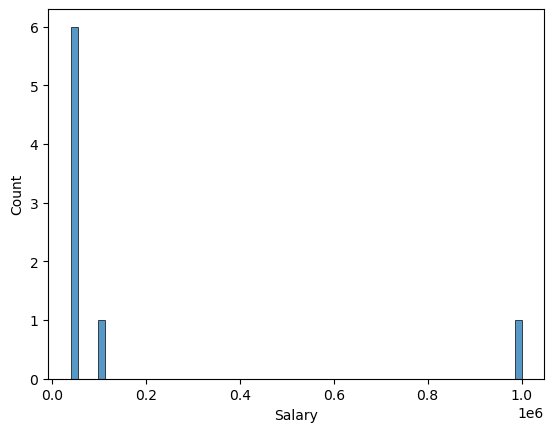

In [36]:
sns.histplot(df['Salary'])
plt.show()

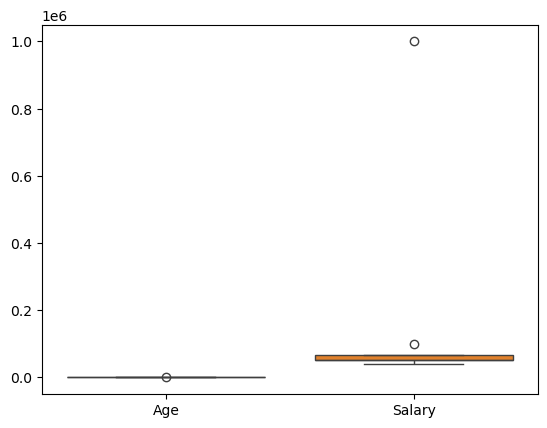

In [37]:
sns.boxplot(df)
plt.show()

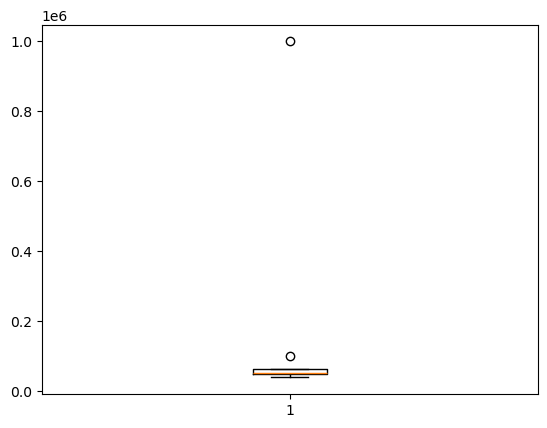

In [38]:
plt.boxplot(df['Salary'])
plt.show()

In [39]:
df

,Age,Salary
0,20,40000
1,25,50000
2,27,52000
3,29,51000
4,31,53000
5,32,54000
6,120,1000000
7,45,100000


In [40]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(":"*50)
print(f"Lower : {lower}\t\t\tUpper : {upper}")
print(":"*50)
print(f"Q1 : {Q1}\tQ3 : {Q3} \tQ2/IQR : {IQR}")
print(":"*50)

::::::::::::::::::::::::::::::::::::::::::::::::::
Lower : 28625.0			Upper : 87625.0
::::::::::::::::::::::::::::::::::::::::::::::::::
Q1 : 50750.0	Q3 : 65500.0 	Q2/IQR : 14750.0
::::::::::::::::::::::::::::::::::::::::::::::::::


In [42]:
outliers = df[ (df["Salary"] < lower) | (df["Salary"] > upper) ]
display(outliers)

,Age,Salary
6,120,1000000
7,45,100000


In [43]:
df_without_ot = df[ (df['Salary'] >= lower) & (df['Salary'] <= upper)]
df_without_ot

,Age,Salary
0,20,40000
1,25,50000
2,27,52000
3,29,51000
4,31,53000
5,32,54000


<hr style="height:2.5px;">

# Method 2: Z-Score Method
    Definition
        Z-score measures how many standard deviations a value lies from the mean.
    
    Formula
        Z = (xi − μ) / σ
    
    Mechanism:
        Compute mean and standard deviation
        Standardize each observation
        Flag observations with large absolute Z values
    
    Decision Rule
        Common threshold:
            ∣Z∣ > 3 
    
    Why It Works
        Under normal distribution:
            99.7% of data lies within ±3σ
            values beyond this are rare
    
    Limitations
        Sensitive to skewness because mean and standard deviation are not robust.
    
    When to Use
        approximately normal data
        large datasets
        symmetric distributions

In [48]:
from scipy import stats
z_scores = np.abs(stats.zscore(df["Salary"]))
print(":"*50)
print(z_scores)
print(":"*50)
outliers = df[z_scores > 3]
print(outliers)

::::::::::::::::::::::::::::::::::::::::::::::::::
[0.43230999 0.40028703 0.39388244 0.39708473 0.39068014 0.38747784
 2.64189439 0.24017222]
::::::::::::::::::::::::::::::::::::::::::::::::::
Empty DataFrame
Columns: [Age, Salary]
Index: []


<hr style="height:2.5px;">

# Method 3: Modified Z-Score (Robust)
        Definition
            A robust alternative to Z-score that uses median and MAD (Median Absolute Deviation).
                                                                      
        Step 1: Median
            Median = middle value
        
        Step 2: MAD
            MAD = median(∣ xi − Median ∣)
            
        Step 3: Modified Z-score
            Mi = 0.6745(xi − Median) / MAD
        
        Constant 0.6745 makes MAD comparable to standard deviation under normality.
        
        Decision Rule
            ∣ Mi ∣ > 3.5
        
        Why It Works
            Median and MAD are resistant to extreme values, making this method robust.
        
        When to Use
            skewed data
            small datasets
            presence of extreme values

In [49]:
median = df["Salary"].median()
mad = np.median(np.abs(df["Salary"] - median))
modified_z = 0.6745 * (df["Salary"] - median) / mad
outliers = df[np.abs(modified_z) > 3.5]
display(outliers)

,Age,Salary
0,20,40000
6,120,1000000
7,45,100000


<hr style="height:2.5px;">

# Method 4: Percentile Method
    Definition
        Removes extreme tails of the distribution based on percentiles.
    .
    Mechanism
        Choose lower and upper percentiles:
        P(low) , P(high)
    
    
    Keep observations such that:
        P(low) ≤ x ≤ P(high)
    
    Example
        Keep between 1st and 99th percentile.
    
    When to Use
        very large datasets
        financial data
        heavy-tailed distributions

In [ ]:
low = df["Salary"].quantile(0.01)
high = df["Salary"].quantile(0.99)
print(":"*100)
print(f"lower : {low}\t\t\tupper: {high}")
print(":"*100)
display(df[ (df['Salary'] < low) | (df['Salary'] > high) ])
print(":"*100)
df_trimmed = df[(df["Salary"] >= low) & (df["Salary"] <= high)]
display(df_trimmed)

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
lower : 40700.0			upper: 936999.9999999998
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::


,Age,Salary
0,20,40000
6,120,1000000


::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::


,Age,Salary
1,25,50000
2,27,52000
3,29,51000
4,31,53000
5,32,54000
7,45,100000


<hr style="height:2.5px;">

# Outlier Treatment Methods
    Detection identifies outliers. Treatment decides what to do with them.

    Treatment 1: Removal (Trimming)
        Definition
            Delete observations identified as outliers.

        Mathematical Operation
            D(clean) = D − {outliers}
        
        Mechanism
            detect bounds
            filter dataset
            remove extreme rows

        When to Use
            clear data entry errors
            impossible values
            very small proportion of outliers

In [54]:
df_removed = df[(df["Salary"] >= lower) & (df["Salary"] <= upper)]
df_removed

,Age,Salary
0,20,40000
1,25,50000
2,27,52000
3,29,51000
4,31,53000
5,32,54000


<hr style="height:2.5px;">

# Treatment 2: Capping (Winsorization)
    Definition
        Replace extreme values with boundary values instead of removing them.
    
    Mathematical Rule
    
             ⎧   Lower Bound, x < Lower Bound
        x =  ⎨   Upper Bound, x > Upper Bound
             ⎩    x, otherwise
    
    Mechanism
        preserves row count
        reduces extreme influence
        keeps distribution shape
    
    When to Use
        outliers are real but extreme
        financial data
        production pipelines

In [56]:
print(f"Lower values: {lower}\nUpper value: {upper}")

Lower values: 28625.0
Upper value: 87625.0


In [57]:
df["Salary_capped"] = np.where(
    df["Salary"] > upper,
    upper,
    np.where(df["Salary"] < lower, lower, df["Salary"])
)
df

,Age,Salary,Salary_capped
0,20,40000,40000.0
1,25,50000,50000.0
2,27,52000,52000.0
3,29,51000,51000.0
4,31,53000,53000.0
5,32,54000,54000.0
6,120,1000000,87625.0
7,45,100000,87625.0


<hr style="height:2.5px;">

# Treatment 3: Transformation
    Definition
        Apply mathematical transformation to reduce skewness and compress extreme values.
    
    Log Transformation
        x′ = log(x)
    
    Mechanism
        compresses large values
        reduces right skew
        stabilizes variance
    
    When to Use
        exponential growth
        right-skewed income data
        count data

In [58]:
df["Salary_log"] = np.log(df["Salary"])
df

,Age,Salary,Salary_capped,Salary_log
0,20,40000,40000.0,10.596635
1,25,50000,50000.0,10.819778
2,27,52000,52000.0,10.858999
3,29,51000,51000.0,10.839581
4,31,53000,53000.0,10.878047
5,32,54000,54000.0,10.896739
6,120,1000000,87625.0,13.815511
7,45,100000,87625.0,11.512925


<hr style="height:2.5px;">

# Treatment 4: Binning
    Definition
        Convert continuous variable into discrete intervals.
    
    Formula
        Equal width binning:
        width = max−min / k
    
    
    Where 
        k is number of bins.
    
    Mechanism
        reduces effect of extreme values
        simplifies distribution
    
    When to Use
        rule-based systems
        scorecards
        interpretability needs

In [59]:
df["Salary_bin"] = pd.cut(df["Salary"], bins=3)
df

,Age,Salary,Salary_capped,Salary_log,Salary_bin
0,20,40000,40000.0,10.596635,"(39040.0, 360000.0]"
1,25,50000,50000.0,10.819778,"(39040.0, 360000.0]"
2,27,52000,52000.0,10.858999,"(39040.0, 360000.0]"
3,29,51000,51000.0,10.839581,"(39040.0, 360000.0]"
4,31,53000,53000.0,10.878047,"(39040.0, 360000.0]"
5,32,54000,54000.0,10.896739,"(39040.0, 360000.0]"
6,120,1000000,87625.0,13.815511,"(680000.0, 1000000.0]"
7,45,100000,87625.0,11.512925,"(39040.0, 360000.0]"


<hr style="height:2.5px;">

# Recommended Practical Workflow
    
    Visualize data (boxplot or histogram)
    Identify outliers using IQR
    Verify with domain knowledge
    Choose treatment (remove or cap)
    Re-evaluate distribution

# Decision Guide

    Use IQR when:
        data is skewed
        dataset is small
        doing tabular ML

    Use Z-score when:
        data is normal
        dataset is large

    Use capping when: 
        outliers are valid but extreme
    
    Use removal when:
        data errors are confirmed

<hr style="height:2.5px;">

# Handling Noisy Data 
    1. Definition of Noisy Data
        Noisy data refers to observations that contain random errors, distortions, or irrelevant variations that obscure 
        the true underlying pattern of the data.

    Formally, an observed value can be modeled as:
        X(observed) = X(true) + ϵ

    Where:
        X(true) = true signal
        ϵ = random noise term

    Noise typically has:
        E(ϵ)=0 , Var(ϵ) = σ^2
    
    2. Sources of Noise
        Noise may arise from:
        sensor measurement errors
        manual data entry mistakes
        transmission errors
        environmental fluctuations
        rounding errors
        system instability

# Example Dataset
    We will simulate noisy data for demonstration.

In [14]:
import pandas as pd
import numpy as np

np.random.seed(42)

# True signal
x = np.arange(1, 21)
true_salary = 50000 + x * 1000
wihtout_noise_df = pd.DataFrame(
      { "Experience" : x ,
       "Salary": true_salary}
)
display(wihtout_noise_df)

,Experience,Salary
0,1,51000
1,2,52000
2,3,53000
3,4,54000
4,5,55000
5,6,56000
6,7,57000
7,8,58000
8,9,59000
9,10,60000


In [16]:
# Add noise
noise = np.random.normal(0, 5000, size=len(x))
salary_noisy = true_salary + noise

df = pd.DataFrame({
    "Experience": x,
    "Salary" : true_salary,
    "noisy_Salary": salary_noisy
})

display(df.head())

,Experience,Salary,noisy_Salary
0,1,51000,58328.243845
1,2,52000,50871.118498
2,3,53000,53337.641023
3,4,54000,46876.259069
4,5,55000,52278.086377


---
# Major Methods to Handle Noisy Data

## Method 1: Binning
    Definition
        Binning is a smoothing technique that groups continuous values into intervals and replaces values within each bin using a representative statistic.
    
    Mechanism
        The idea is to reduce random fluctuations by averaging nearby values.

    Types of Binning
    
    1. Equal Width Binning
        Formula
            width = max(X)−min(X) / k 
    
        Where 
        k is number of bins.
    
        Each bin interval:
        [min + i ⋅ width , min + (i+1) ⋅ width]

    2. Equal Frequency Binning
        Each bin contains approximately equal number of observations.

    3. Bin Smoothing
        Within each bin, values can be replaced by:
        bin mean
        bin median
        bin boundaries
  
### --Use Cases
            reducing small random fluctuations
            preprocessing for rule-based systems
            discretization tasks      

In [ ]:
# Equal width binning
df["Salary_bin"] = pd.cut(df["Salary"], bins=4)

# Bin mean smoothing
df["Salary_smooth"] = df.groupby("Salary_bin")["Salary"].transform("mean")

display(df.head())

C:\Users\dmin\AppData\Local\Temp\ipykernel_8352\1413927526.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["Salary_smooth"] = df.groupby("Salary_bin")["Salary"].transform("mean")


,Experience,Salary,noisy_Salary,Salary_bin,Salary_smooth
0,1,51000,58328.243845,"(50981.0, 55750.0]",53000.0
1,2,52000,50871.118498,"(50981.0, 55750.0]",53000.0
2,3,53000,53337.641023,"(50981.0, 55750.0]",53000.0
3,4,54000,46876.259069,"(50981.0, 55750.0]",53000.0
4,5,55000,52278.086377,"(50981.0, 55750.0]",53000.0


---
# Method 2: Moving Average (Time-Series Smoothing)
    Definition
        Moving average smooths data by replacing each value with the average of its neighboring observations.
    
    Mathematical Formula
        Simple moving average (window size = k):
                MAt = (1 / k) [i=t−k+1] ∑ t (Xi)

    Mechanism
        slides a window over data
        averages local neighborhood
        reduces high-frequency noise

    Types
        Simple Moving Average (SMA)
            Equal weight to all points.
        
        Weighted Moving Average (WMA)        
            Different weights assigned.
        
        Exponential Moving Average (EMA)
            Recent values weighted more.
    Use Cases
        time-series smoothing
        stock price analysis
        sensor data cleaning

In [18]:
# Simple moving average
df["Salary_SMA"] = df["Salary"].rolling(window=3).mean()

display(df.head())

,Experience,Salary,noisy_Salary,Salary_bin,Salary_smooth,Salary_SMA
0,1,51000,58328.243845,"(50981.0, 55750.0]",53000.0,NaN
1,2,52000,50871.118498,"(50981.0, 55750.0]",53000.0,NaN
2,3,53000,53337.641023,"(50981.0, 55750.0]",53000.0,52000.0
3,4,54000,46876.259069,"(50981.0, 55750.0]",53000.0,53000.0
4,5,55000,52278.086377,"(50981.0, 55750.0]",53000.0,54000.0


---
# Method 3: Regression-Based Smoothing
    Definition
        Fit a regression model to capture the underlying trend and use predicted values as smoothed estimates.
        Mathematical Model
    
    Linear regression:
        Y = β0 + β1X + ϵ
    
    Smoothed value:
        𝑌^ = β0 + β1X
    
    Mechanism
        fit model to noisy data
        capture trend
        remove random fluctuations
    
    Use Cases
        trend extraction
        forecasting preprocessing
        removing random noise

In [19]:
from sklearn.linear_model import LinearRegression

X = df[["Experience"]]
y = df["Salary"]

model = LinearRegression()
model.fit(X, y)

df["Salary_reg_smooth"] = model.predict(X)

display(df.head())

,Experience,Salary,noisy_Salary,Salary_bin,Salary_smooth,Salary_SMA,Salary_reg_smooth
0,1,51000,58328.243845,"(50981.0, 55750.0]",53000.0,NaN,51000.0
1,2,52000,50871.118498,"(50981.0, 55750.0]",53000.0,NaN,52000.0
2,3,53000,53337.641023,"(50981.0, 55750.0]",53000.0,52000.0,53000.0
3,4,54000,46876.259069,"(50981.0, 55750.0]",53000.0,53000.0,54000.0
4,5,55000,52278.086377,"(50981.0, 55750.0]",53000.0,54000.0,55000.0


---
# Method 4: Clustering-Based Noise Handling
    Definition
        Noise points are detected as observations that do not belong strongly to any cluster.
    
    Mechanism
        In clustering (e.g., K-means):
            dense regions form clusters
            isolated points are likely noise
    
    Distance to centroid:
        d(x,c) = sqrt( ∑( xi − ci )^2)
    
    
    Points with very large distance are treated as noisy.
    
    Use Cases
        anomaly detection
        spatial data
        customer segmentation

In [21]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
df["cluster"] = kmeans.fit_predict(df[["Salary"]])

centers = kmeans.cluster_centers_

# distance from assigned centroid
df["dist"] = abs(df["Salary"] - df["cluster"].map({0: centers[0][0], 1: centers[1][0]}))
df['clustering_smooth'] = (df['noisy_Salary'] - df['dist'])

display(df.head())

E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Experience,Salary,noisy_Salary,Salary_bin,Salary_smooth,Salary_SMA,Salary_reg_smooth,cluster,dist,clustering_smooth
0,1,51000,58328.243845,"(50981.0, 55750.0]",53000.0,NaN,51000.0,0,5000.0,53328.243845
1,2,52000,50871.118498,"(50981.0, 55750.0]",53000.0,NaN,52000.0,0,4000.0,46871.118498
2,3,53000,53337.641023,"(50981.0, 55750.0]",53000.0,52000.0,53000.0,0,3000.0,50337.641023
3,4,54000,46876.259069,"(50981.0, 55750.0]",53000.0,53000.0,54000.0,0,2000.0,44876.259069
4,5,55000,52278.086377,"(50981.0, 55750.0]",53000.0,54000.0,55000.0,0,1000.0,51278.086377


---
# Method 5: Low-Pass Filtering (Conceptual)
Definition
    Low-pass filters remove high-frequency components (noise) while preserving low-frequency signal.
    
    In discrete form, moving average is a simple low-pass filter.

    General Convolution Formula

        Yt = [k - i=−k] ∑ (wi)(Xt+i)
        Where wi are filter weights.

    Use Cases
    
    signal processing
    IoT sensor data
    audio smoothing

---
# Method 6: Robust Statistical Methods

    Instead of modifying data, use robust statistics:
        median instead of mean
        MAD instead of standard deviation
        quantile regression
    
    When to Prefer
        heavy noise
        presence of outliers
        real-time systems

# Practical End-to-End Pipeline

In [22]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

np.random.seed(42)

x = np.arange(1, 21)
true_salary = 50000 + x * 1000
noise = np.random.normal(0, 5000, size=len(x))
salary_noisy = true_salary + noise

df = pd.DataFrame({
    "Experience": x,
    "Salary": salary_noisy
})

# Moving average smoothing
df["Salary_SMA"] = df["Salary"].rolling(window=3).mean()

# Regression smoothing
model = LinearRegression()
model.fit(df[["Experience"]], df["Salary"])
df["Salary_reg_smooth"] = model.predict(df[["Experience"]])

display(df.head())

,Experience,Salary,Salary_SMA,Salary_reg_smooth
0,1,53483.570765,NaN,54872.833168
1,2,51308.678494,NaN,55375.009381
2,3,56238.442691,53676.897317,55877.185594
3,4,61615.149282,56387.423489,56379.361807
4,5,53829.233126,57227.608366,56881.538021


---
# Decision Guide

    Use binning when:
        need discretization
        simple smoothing required
    
    Use moving average when:
        time-series data
        sequential measurements
    
    Use regression smoothing when:
        clear trend exists
        predictive modeling needed
    
    Use clustering when:
        spatial or multidimensional data
        anomaly detection
    
    Use robust statistics when:
        heavy noise and outliers
        production ML systems

---

<hr style="height:2.5px;">

# Encoding Categorical Variables
    1. Definition
        Categorical variables are variables that represent qualitative attributes or categories rather than numerical quantities.

    Examples:
    
        Feature	              Type
        
        Gender	              Male / Female
        City	              Delhi / Mumbai / Chennai
        Education	             High School / Bachelor / Master
        Purchased	             Yes / No
    
        Machine learning algorithms generally operate on numerical matrices, meaning categorical data must be transformed into numeric 
        representations   before modeling.

        This transformation process is called categorical encoding.   

---
# 2. Types of Categorical Variables
    2.1 Nominal Variables
        Nominal variables have categories with no inherent order.
            
    Example:
        City = {Delhi, Mumbai, Chennai}
        There is no meaningful ordering.
    
    2.2 Ordinal Variables
        Ordinal variables have categories with a natural ranking.
    
    Example:
        Education Level
        High School < Bachelor < Master < PhD
    
    The ordering carries information.

---
# 3. Why Encoding Is Necessary
        Many algorithms compute distances, gradients, or matrix operations.

    Example: Euclidean distance
        d(x,y) = [i=1 - n] ∑ (xi − yi )^2


If categorical values remain as strings, these operations cannot be performed.
Therefore categorical values must be transformed into numeric feature vectors.

---
# Example Dataset
    We will use the following dataset.

In [3]:
import pandas as pd

data = {
    "City": ["Delhi", "Mumbai", "Chennai", "Delhi", "Mumbai"],
    "Education": ["Bachelor", "Master", "PhD", "Bachelor", "Master"],
    "Purchased": ["Yes", "No", "Yes", "No", "Yes"]
}
df = pd.DataFrame(data)
display(df)

,City,Education,Purchased
0,Delhi,Bachelor,Yes
1,Mumbai,Master,No
2,Chennai,PhD,Yes
3,Delhi,Bachelor,No
4,Mumbai,Master,Yes


---
# Major Encoding Techniques
    1. Label Encoding
        Definition
            Label encoding converts each category into a unique integer value.

    Example:
        City	    Encoded
        Chennai	       0
        Delhi	       1
        Mumbai	       2

    Mathematical Representation
        If a categorical variable has k categories:
            C = { c1, c2 ,..., ck }
        
        Label encoding defines a mapping:
            f(ci) = i
        
        Where i is an integer index.

    Mechanism
        Identify unique categories
        Assign integer labels
        Replace categories with labels

    Use Cases
        Appropriate for:
        Ordinal variables

   Limitations
   
        For nominal variables, label encoding introduces false ordinal relationships.
        
        Example:
            Delhi = 1
            Mumbai = 2
    
    Model may assume Mumbai > Delhi. 

In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df["City_Label"] = le.fit_transform(df["City"])
display(df)

,City,Education,Purchased,City_Label
0,Delhi,Bachelor,Yes,1
1,Mumbai,Master,No,2
2,Chennai,PhD,Yes,0
3,Delhi,Bachelor,No,1
4,Mumbai,Master,Yes,2


---
# 2. One-Hot Encoding
    Definition
        One-hot encoding converts each category into a binary vector representation.
        Each category becomes a new column.

    Mathematical Representation
        For a categorical variable with 𝑘 categories:
            C = { c1 , c2 ,..., ck}

    Each category is mapped to a k-dimensional binary vector.

        Example:
        Delhi          (1,0,0)
        Mumbai         (0,1,0)
        Chennai        (0,0,1)

    Mechanism
            Identify unique categories
            Create binary columns
            Assign 1 if row belongs to category, otherwise 0
    
    Advantages
        No artificial ordering.

    Limitations
        When number of categories is large:
                Number of columns = k 
        
        This leads to high dimensionality.

    Use Cases
        Most widely used method for:
            logistic regression
            neural networks
            decision tree

In [5]:
df_encoded = pd.get_dummies(df, columns=["City"])
display(df_encoded)

,Education,Purchased,City_Label,City_Chennai,City_Delhi,City_Mumbai
0,Bachelor,Yes,1,False,True,False
1,Master,No,2,False,False,True
2,PhD,Yes,0,True,False,False
3,Bachelor,No,1,False,True,False
4,Master,Yes,2,False,False,True


---
# 3. Dummy Encoding
    Definition
        Dummy encoding is a variation of one-hot encoding that removes one category column to prevent multicollinearity.
    
    Mathematical Explanation
        If 𝑘 categories exist:
            One-hot encoding creates 𝑘 columns.

    Dummy encoding creates:
                k−1

    columns.
        The removed category becomes the reference category.

    Mechanism
        If three categories exist:
        Delhi, Mumbai, Chennai
        One column removed.

    Example:
        City_Mumbai	        City_Chennai
        0	                0 → Delhi
        1	                0 → Mumbai
        0	                1 → Chennai

    Use Case
        Used in linear regression to avoid:
                X1 + X2 + X3 = 1
        This linear dependency causes multicollinearity.

In [6]:
df_dummy = pd.get_dummies(df, columns=["City"], drop_first=True)
display(df_dummy)

,Education,Purchased,City_Label,City_Delhi,City_Mumbai
0,Bachelor,Yes,1,True,False
1,Master,No,2,False,True
2,PhD,Yes,0,False,False
3,Bachelor,No,1,True,False
4,Master,Yes,2,False,True


---
# 4. Frequency Encoding
    Definition
        Each category is replaced with its frequency in the dataset.

    Formula
        For category 
            f( ci ) = count( ci ) / N

        Where
            𝑁 = total observations.

    Mechanism
        Example dataset:
            City
            Delhi
            Delhi
            Mumbai
            Chennai

    Frequencies:
        Delhi = 2/4 = 0.5
        Mumbai = 1/4 = 0.25
        Chennai = 1/4 = 0.25

    Use Cases
        large datasets
        high-cardinality features
        tree-bcccsed models

In [7]:
freq = df["City"].value_counts() / len(df)
df["City_freq"] = df["City"].map(freq)
display(df)

,City,Education,Purchased,City_Label,City_freq
0,Delhi,Bachelor,Yes,1,0.4
1,Mumbai,Master,No,2,0.4
2,Chennai,PhD,Yes,0,0.2
3,Delhi,Bachelor,No,1,0.4
4,Mumbai,Master,Yes,2,0.4


---
# 5. Target Encoding (Mean Encoding)
    Definition
        Categories are encoded using the mean of the target variable.

    Mathematical Formula
        For category 
            TE(ci) = (∑ yj) / ni

    Where
        𝑦𝑗 = target values for category
        𝑛𝑖 = number of observations in that category.

    Mechanism
                
    Example dataset:
        City	    Purchased
        Delhi	    Yes
        Delhi	    No
        Mumbai	    Yes

    Convert Yes = 1, No = 0
        Mean for Delhi:
            (1+0)/2 = 0.5
        Mumbai:
            1/1=1
    
    Use Cases
        high-cardinality categorical variables
        gradient boosting models

In [8]:
df["Purchased_num"] = df["Purchased"].map({"Yes":1,"No":0})
target_mean = df.groupby("City")["Purchased_num"].mean()
df["City_target"] = df["City"].map(target_mean)
display(df)

,City,Education,Purchased,City_Label,City_freq,Purchased_num,City_target
0,Delhi,Bachelor,Yes,1,0.4,1,0.5
1,Mumbai,Master,No,2,0.4,0,0.5
2,Chennai,PhD,Yes,0,0.2,1,1.0
3,Delhi,Bachelor,No,1,0.4,0,0.5
4,Mumbai,Master,Yes,2,0.4,1,0.5


---
# 6. Binary Encoding
    Definition
        Binary encoding converts categories to integers and then to binary representation.

    Mechanism
        Step 1: Label encode categories.
        Step 2: Convert integer to binary.

    Example:
    
        City	  Label	  Binary
        Delhi	  1	      001
        Mumbai	  2	      010
        Chennai	  3	      011
    
    Advantages
        Reduces dimensionality compared to one-hot encoding.

    Use Cases
        datasets with many categories
        memory-efficient modeling

In [10]:
import pandas as pd

data = {
    "City": ["Delhi","Mumbai","Chennai","Delhi","Mumbai"],
    "Education": ["Bachelor","Master","PhD","Bachelor","Master"]
}

df = pd.DataFrame(data)


df = pd.get_dummies(df, columns=["City"])

display(df)

,Education,City_Chennai,City_Delhi,City_Mumbai
0,Bachelor,False,True,False
1,Master,False,False,True
2,PhD,True,False,False
3,Bachelor,False,True,False
4,Master,False,False,True


---
# When to Use Each Encoding Technique
    Technique	               Best Use Case
    Label Encoding	           ordinal variables
    One-Hot Encoding	       nominal variables
    Dummy Encoding	           regression models
    Frequency Encoding	       high-cardinality features
    Target Encoding	           predictive modeling
    Binary Encoding	           memory-efficient encoding
---

<hr style="height:2.5px;">

# Feature Scaling
    1. Definition
        Feature scaling is a data preprocessing technique used to transform numerical features 
        into a common scale without distorting the relationships between values.
        In many datasets, different features may have vastly different ranges.

    Example:
        Feature	Range
        Age	18 – 60
        Salary	20,000 – 1,000,000

    If such features are used directly in machine learning algorithms, the feature with the larger
    magnitude dominates the learning process.

    Feature scaling ensures that all features contribute equally to the model training process.

---
# 2. Why Feature Scaling Is Necessary
    Many machine learning algorithms rely on distance calculations, gradient optimization, or 
    variance-based calculations.

    Example: Euclidean distance
        d(x,y) = [i=1 -> n] ∑ (xi − yi)^2
        If one feature has a much larger scale, it dominates the distance.

    Example:
        Feature             	Value
        Age difference	        5
        Salary difference	    200000

    Distance will mainly depend on salary.

---
# 3. Algorithms That Require Feature Scaling
    
    Algorithms sensitive to feature magnitude:
        K-Nearest Neighbors
        K-Means Clustering
        Support Vector Machines
        Linear Regression with gradient descent
        Logistic Regression
        Neural Networks
        Principal Component Analysis

    Algorithms generally insensitive:
        Decision Trees
        Random Forest
        Gradient Boosting Trees

---
# Example Dataset
        We will use this dataset to demonstrate scaling methods.

In [10]:
import pandas as pd

data = {
    "Age": [25, 30, 35, 40, 45, 50, 25 , 30],
    "Salary": [20000, 50000, 80000, 120000, 200000, 100000, 25000, 60000]
}
df = pd.DataFrame(data)
display(df)

,Age,Salary
0,25,20000
1,30,50000
2,35,80000
3,40,120000
4,45,200000
5,50,100000
6,25,25000
7,30,60000


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

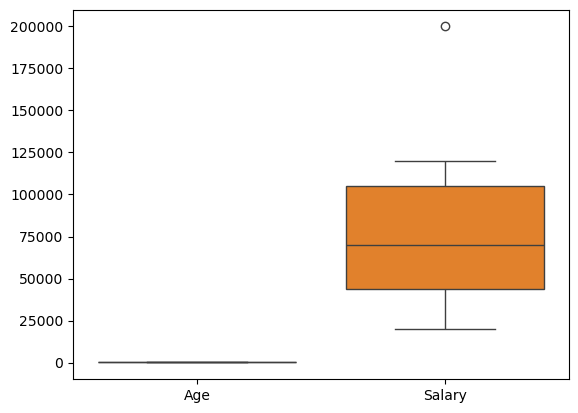

In [14]:
sns.boxplot(df)
plt.show()

---
# Types of Feature Scaling Methods
    Min-Max Normalization
    Standardization (Z-score scaling)
    Robust Scaling
    Max Absolute Scaling
    Unit Vector Scaling (Normalization)
    Log Transformation (distribution-based scaling)

---
# 1. Min-Max Normalization
    Definition
        Min-Max scaling transforms values so that they fall within a fixed interval, typically 
        between 0 and 1.

    Mathematical Formula
        x′ = x − xmin / xm𝑎x - xmin
    
    
    Where
        x = original value
        xmin = minimum value in feature
        xmax = maximum value in feature
        x′ = scaled value
    
    Mechanism
        Identify minimum and maximum values of the feature.
        Subtract the minimum from each observation.
        Divide by the range.
    
    This ensures:
        0 ≤ x′ ≤ 1

# Example Calculation

    Suppose salary values:
    20000, 50000, 80000
    
    Minimum = 20000
    Maximum = 80000
    
    For value = 50000
    𝑥′ = 50000 − 20000 / 80000 − 20000
    x′ = 30000 / 60000 = 0.5

    For value = 20000
    x` = 20000 - 20000 / 80000 - 20000 -> 0

    For value = 80000
    x` = 80000 - 20000 / 80000 - 20000 -> 1

# Use Cases
    Suitable when:
    features have known boundaries
    neural networks are used
    data distribution is not extreme

In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)
df_minmax = pd.DataFrame(scaled, columns=df.columns)
print(":"*50, "Before Scaling" ,":"*50)
display(df)
print(":"*50, "After Scaling" ,":"*50)
display(df_minmax)

:::::::::::::::::::::::::::::::::::::::::::::::::: Before Scaling ::::::::::::::::::::::::::::::::::::::::::::::::::


,Age,Salary
0,25,20000
1,30,50000
2,35,80000
3,40,120000
4,45,200000
5,50,100000
6,25,25000
7,30,60000


:::::::::::::::::::::::::::::::::::::::::::::::::: After Scaling ::::::::::::::::::::::::::::::::::::::::::::::::::


,Age,Salary
0,0.0,0.000000
1,0.2,0.166667
2,0.4,0.333333
3,0.6,0.555556
4,0.8,1.000000
5,1.0,0.444444
6,0.0,0.027778
7,0.2,0.222222


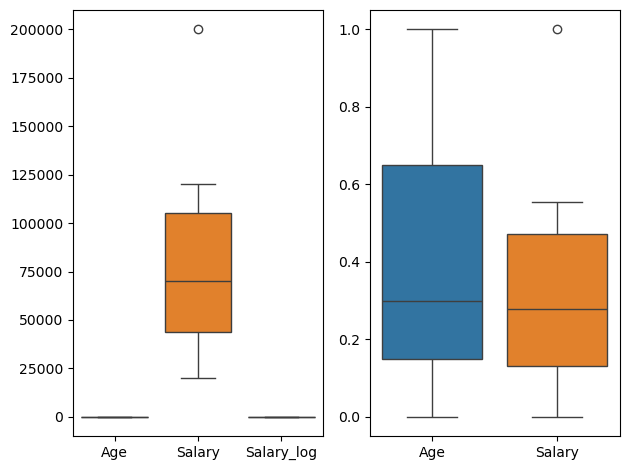

In [50]:
plt.subplot(1,2,1)
sns.boxplot(df)

plt.subplot(1,2,2)
sns.boxplot(df_minmax)

plt.tight_layout()
plt.show()

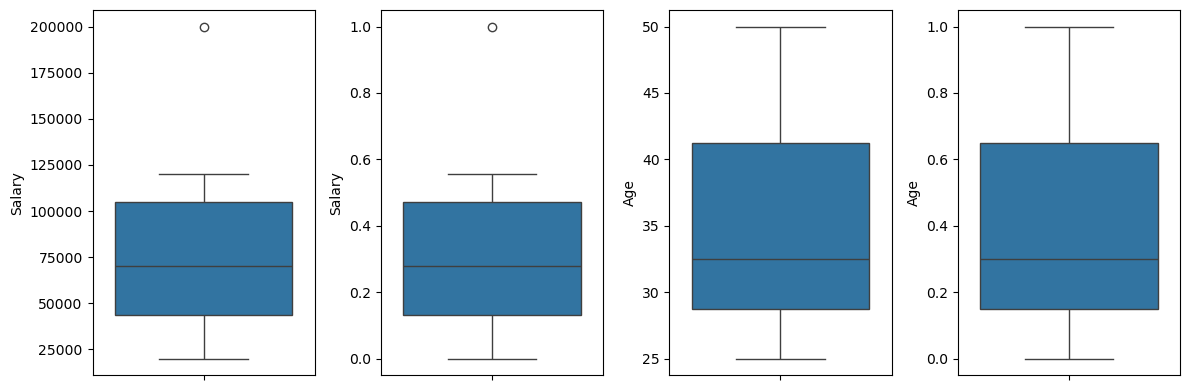

In [49]:
plt.figure(figsize=(12,4))
plt.subplot(1,4,1)
sns.boxplot(df['Salary'])

plt.subplot(1,4,2)
sns.boxplot(df_minmax['Salary'])

plt.subplot(1,4,3)
sns.boxplot(df['Age'])

plt.subplot(1,4,4)
sns.boxplot(df_minmax['Age'])

plt.tight_layout()
plt.show()

---
# 2. Standardization (Z-score Scaling)
    Definition
        Standardization transforms data so that the feature has:
        mean = 0
        standard deviation = 1
        
        𝑧 = 𝑥 − 𝜇 / 𝜎
    
        where 
        x = original value
        μ = mean of the feature
        σ = standard deviation
    
# Mechanism
        Compute mean of the feature.
        Compute standard deviation.
        Center the data around zero by subtracting mean.
        Scale using standard deviation.
    
# Example Calculation
    Suppose:
    
        Mean salary = 100000
        Standard deviation = 50000
        For salary = 150000
    
        𝑧 = 150000 − 100000 / 50000
        z=1
        This means the value is one standard deviation above the mean.
    
# Use Cases
    Best suited for:
        normally distributed data
        gradient-based algorithms
        linear regression
        support vector machines

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled = scaler.fit_transform(df)
df_standard = pd.DataFrame(scaled, columns=df.columns)
print(":"*50, "Before Scaling" ,":"*50)
display(df)
print(":"*50, "After Scaling" ,":"*50)
display(df_standard)

:::::::::::::::::::::::::::::::::::::::::::::::::: Before Scaling ::::::::::::::::::::::::::::::::::::::::::::::::::


,Age,Salary
0,25,20000
1,30,50000
2,35,80000
3,40,120000
4,45,200000
5,50,100000
6,25,25000
7,30,60000


:::::::::::::::::::::::::::::::::::::::::::::::::: After Scaling ::::::::::::::::::::::::::::::::::::::::::::::::::


,Age,Salary
0,-1.154701,-1.122755
1,-0.577350,-0.578389
2,0.000000,-0.034023
3,0.577350,0.691799
4,1.154701,2.143441
5,1.732051,0.328888
6,-1.154701,-1.032027
7,-0.577350,-0.396934


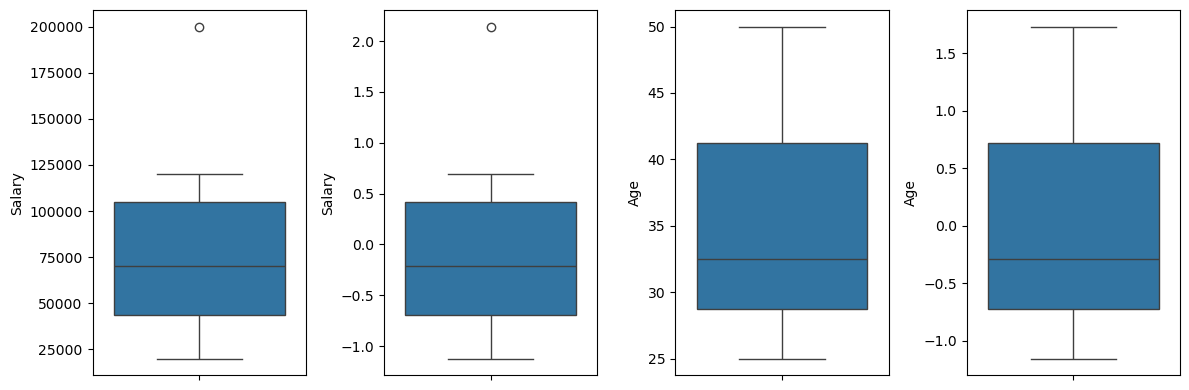

In [48]:
plt.figure(figsize=(12,4))
plt.subplot(1,4,1)
sns.boxplot(df['Salary'])

plt.subplot(1,4,2)
sns.boxplot(df_standard['Salary'])

plt.subplot(1,4,3)
sns.boxplot(df['Age'])

plt.subplot(1,4,4)
sns.boxplot(df_standard['Age'])

plt.tight_layout()
plt.show()

---
# 3. Robust Scaling
    Definition
        Robust scaling uses median and interquartile range (IQR) instead of mean and standard deviation.
        It is less sensitive to outliers.

    Mathematical Formula
        x′ = x − Median / IQR
        Where
                IQR=Q3−Q1
            Q1 = 25th percentile
            Q3 = 75th percentile
    
    Mechanism
        Compute median of feature.
        Compute first and third quartiles.
        Compute IQR.
        Scale values relative to median.
    
    Example
        If:
            Median salary = 80000
            IQR = 50000
            For salary = 120000
            
            𝑥′ = 120000 − 80000 / 50000
            x′ = 0.8
    
    Use Cases
        Suitable when:
        dataset contains outliers
        distribution is skewed
        financial data is used

In [19]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaled = scaler.fit_transform(df)
df_robust = pd.DataFrame(scaled, columns=df.columns)
print(":"*50, "Before Scaling" ,":"*50)
display(df)
print(":"*50, "After Scaling" ,":"*50)
display(df_robust)

:::::::::::::::::::::::::::::::::::::::::::::::::: Before Scaling ::::::::::::::::::::::::::::::::::::::::::::::::::


,Age,Salary
0,25,20000
1,30,50000
2,35,80000
3,40,120000
4,45,200000
5,50,100000
6,25,25000
7,30,60000


:::::::::::::::::::::::::::::::::::::::::::::::::: After Scaling ::::::::::::::::::::::::::::::::::::::::::::::::::


,Age,Salary
0,-0.6,-0.816327
1,-0.2,-0.326531
2,0.2,0.163265
3,0.6,0.816327
4,1.0,2.122449
5,1.4,0.489796
6,-0.6,-0.734694
7,-0.2,-0.163265


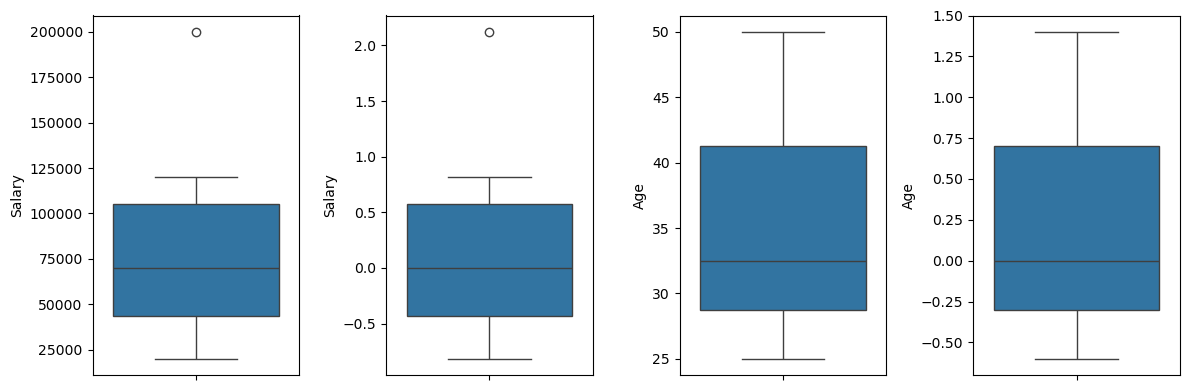

In [47]:
plt.figure(figsize=(12,4))
plt.subplot(1,4,1)
sns.boxplot(df['Salary'])

plt.subplot(1,4,2)
sns.boxplot(df_robust['Salary'])

plt.subplot(1,4,3)
sns.boxplot(df['Age'])

plt.subplot(1,4,4)
sns.boxplot(df_robust['Age'])

plt.tight_layout()
plt.show()

---
# 4. Max Absolute Scaling
    Definition
        Max absolute scaling divides each value by the maximum absolute value of the feature.
    
    Mathematical Formula:
        𝑥′ = 𝑥 / ∣𝑥m𝑎x∣
    
    Mechanism
        Find the maximum absolute value.
        Divide each observation by this value.
        Result range:
            −1 ≤ x` ≤ 1
        
    Use Cases
        sparse datasets
        text data (TF-IDF matrices)
        memory-efficient processing

In [20]:
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()
scaled = scaler.fit_transform(df)
df_maxabs = pd.DataFrame(scaled, columns=df.columns)
print(":"*50, "Before Scaling" ,":"*50)
display(df)
print(":"*50, "After Scaling" ,":"*50)
display(df_maxabs)

:::::::::::::::::::::::::::::::::::::::::::::::::: Before Scaling ::::::::::::::::::::::::::::::::::::::::::::::::::


,Age,Salary
0,25,20000
1,30,50000
2,35,80000
3,40,120000
4,45,200000
5,50,100000
6,25,25000
7,30,60000


:::::::::::::::::::::::::::::::::::::::::::::::::: After Scaling ::::::::::::::::::::::::::::::::::::::::::::::::::


,Age,Salary
0,0.5,0.100
1,0.6,0.250
2,0.7,0.400
3,0.8,0.600
4,0.9,1.000
5,1.0,0.500
6,0.5,0.125
7,0.6,0.300


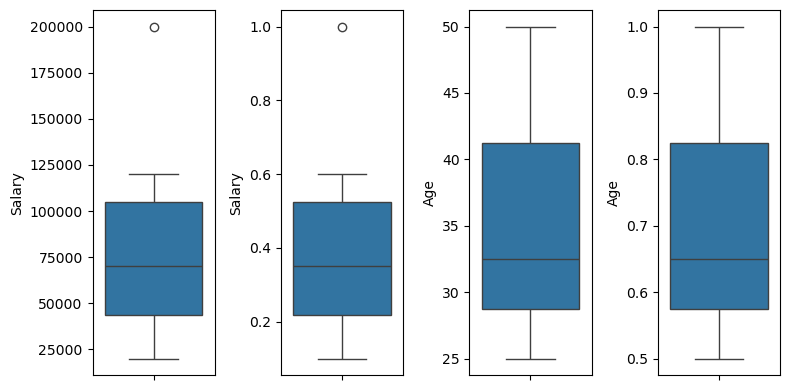

In [46]:
plt.figure(figsize=(8,4))
plt.subplot(1,4,1)
sns.boxplot(df['Salary'])

plt.subplot(1,4,2)
sns.boxplot(df_maxabs['Salary'])

plt.subplot(1,4,3)
sns.boxplot(df['Age'])

plt.subplot(1,4,4)
sns.boxplot(df_maxabs['Age'])

plt.tight_layout()
plt.show()

---
# 5. Unit Vector Scaling (Normalization)
    Definition
        Each data point (row) is scaled so that its vector magnitude equals 1.

    Mathematical Formula
        For vector 𝑋:
        ∣∣ 𝑋 ∣∣ = (𝑥1)^2+ (𝑥2)^2 + . . . + (𝑥𝑛)^2
    
    Normalized vector:
        𝑋′ = 𝑋 / ∣∣ 𝑋 ∣∣
    
    
    Mechanism
        Compute magnitude of feature vector.
        Divide each element by magnitude.

    Example

    Vector:
        (3,4)
    
    Magnitude:
        sqrt((3^2) + (4^2)) =5
    
    Normalized vector:
        (0.6, 0.8)

    Use Cases
        text classification
        cosine similarity
        information retrieval systems

In [21]:
from sklearn.preprocessing import Normalizer
scaler = Normalizer()
scaled = scaler.fit_transform(df)
df_normalized = pd.DataFrame(scaled, columns=df.columns)
print(":"*50, "Before Scaling" ,":"*50)
display(df)
print(":"*50, "After Scaling" ,":"*50)
display(df_normalized)

:::::::::::::::::::::::::::::::::::::::::::::::::: Before Scaling ::::::::::::::::::::::::::::::::::::::::::::::::::


,Age,Salary
0,25,20000
1,30,50000
2,35,80000
3,40,120000
4,45,200000
5,50,100000
6,25,25000
7,30,60000


:::::::::::::::::::::::::::::::::::::::::::::::::: After Scaling ::::::::::::::::::::::::::::::::::::::::::::::::::


,Age,Salary
0,0.001250,0.999999
1,0.000600,1.000000
2,0.000437,1.000000
3,0.000333,1.000000
4,0.000225,1.000000
5,0.000500,1.000000
6,0.001000,1.000000
7,0.000500,1.000000


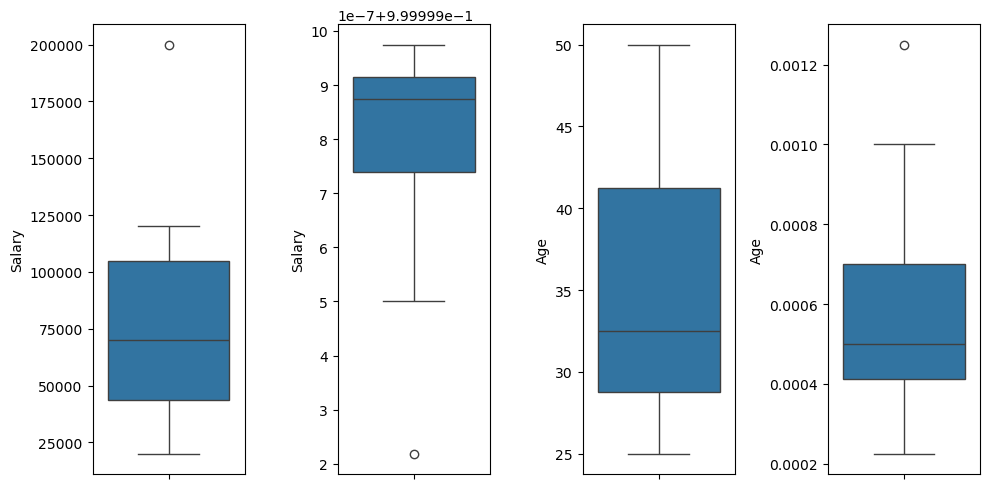

In [43]:
plt.figure(figsize=(10,5))
plt.subplot(1,4,1)
sns.boxplot(df['Salary'])

plt.subplot(1,4,2)
sns.boxplot(df_normalized['Salary'])

plt.subplot(1,4,3)
sns.boxplot(df['Age'])

plt.subplot(1,4,4)
sns.boxplot(df_normalized['Age'])

plt.tight_layout()
plt.show()

---
# 6. Log Transformation
    Definition
        Log transformation compresses large values to reduce skewness.

    Mathematical Formula:
        𝑥′ = log(x)
    
    Mechanism
        Large numbers shrink more than small numbers, making distributions more symmetric.
    
    Use Cases
        income or financial data
        exponential growth variables
        skewed distributions

In [22]:
import numpy as np
df["Salary_log"] = np.log(df["Salary"])
display(df)

,Age,Salary,Salary_log
0,25,20000,9.903488
1,30,50000,10.819778
2,35,80000,11.289782
3,40,120000,11.695247
4,45,200000,12.206073
5,50,100000,11.512925
6,25,25000,10.126631
7,30,60000,11.002100


<Axes: ylabel='Salary_log'>

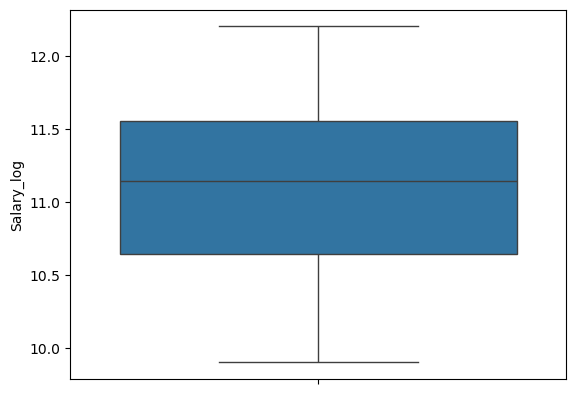

In [24]:
sns.boxplot(df['Salary_log'])

<hr style="height:2.5px;">

In [52]:
datasets = list(sns.get_dataset_names())
datasets

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [59]:
k = sns.load_dataset('titanic')
columns = list(k.columns)
for col in columns:
    print(k[col].dtype)

int64
int64
object
float64
int64
int64
float64
object
category
object
bool
category
object
object
bool


In [67]:
t = sns.load_dataset('taxis')
t['fare'].min()

1.0

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
datasets = sns.get_dataset_names()
datasets

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

:::::::::::::::::::::::::::::::::::::::::::::::::: anagrams ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: subidr
Min: 1		Max: 20		Diffrence: 19

Columns: num1
Min: 2		Max: 8		Diffrence: 6

Columns: num2
Min: 3.0		Max: 9.0		Diffrence: 6.0

Columns: num3
Min: 5		Max: 9		Diffrence: 4
:::::::::::::::::::::::::::::::::::::::::::::::::: anscombe ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: x
Min: 4.0		Max: 19.0		Diffrence: 15.0

Columns: y
Min: 3.1		Max: 12.74		Diffrence: 9.64
:::::::::::::::::::::::::::::::::::::::::::::::::: attention ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: Unnamed: 0
Min: 0		Max: 59		Diffrence: 59

Columns: subject
Min: 1		Max: 20		Diffrence: 19

Columns: solutions
Min: 1		Max: 3		Diffrence: 2

Columns: score
Min: 2.0		Max: 9.0		Diffrence: 7.0
:::::::::::::::::::::::::::::::::::::::::::::::::: brain_networks ::::::::::::::::::::::::::::::::::::::::::::::::::
:::::::::::::::::::::::::::::::::::::::::::::::::: car_crashes 

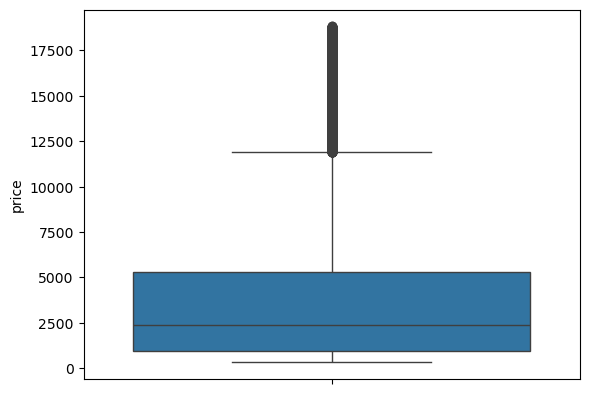


Columns: x
Min: 0.0		Max: 10.74		Diffrence: 10.74

Columns: y
Min: 0.0		Max: 58.9		Diffrence: 58.9

Columns: z
Min: 0.0		Max: 31.8		Diffrence: 31.8
:::::::::::::::::::::::::::::::::::::::::::::::::: dots ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: time
Min: -600		Max: 720		Diffrence: 1320


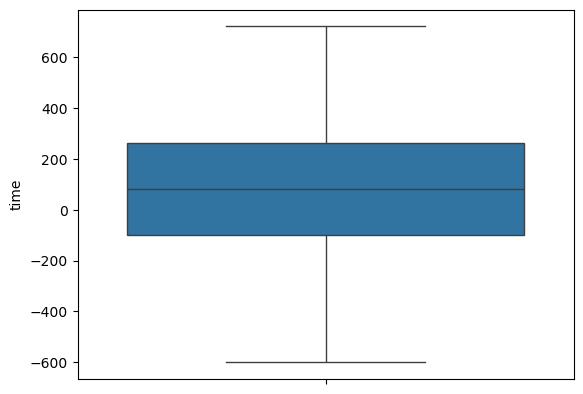


Columns: coherence
Min: 0.0		Max: 51.2		Diffrence: 51.2

Columns: firing_rate
Min: 6.27572016461		Max: 70.0488997555		Diffrence: 63.77317959089
:::::::::::::::::::::::::::::::::::::::::::::::::: dowjones ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: Price
Min: 46.85		Max: 985.93		Diffrence: 939.0799999999999


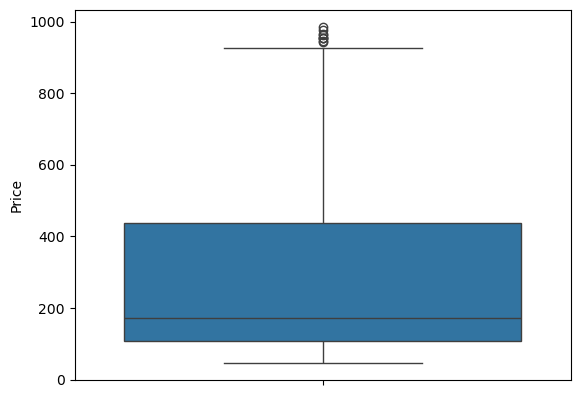

:::::::::::::::::::::::::::::::::::::::::::::::::: exercise ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: Unnamed: 0
Min: 0		Max: 89		Diffrence: 89

Columns: id
Min: 1		Max: 30		Diffrence: 29

Columns: pulse
Min: 80		Max: 150		Diffrence: 70
:::::::::::::::::::::::::::::::::::::::::::::::::: flights ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: year
Min: 1949		Max: 1960		Diffrence: 11

Columns: passengers
Min: 104		Max: 622		Diffrence: 518
:::::::::::::::::::::::::::::::::::::::::::::::::: fmri ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: timepoint
Min: 0		Max: 18		Diffrence: 18

Columns: signal
Min: -0.25548585958		Max: 0.564984721448		Diffrence: 0.820470581028
:::::::::::::::::::::::::::::::::::::::::::::::::: geyser ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: duration
Min: 1.6		Max: 5.1		Diffrence: 3.4999999999999996

Columns: waiting
Min: 43		Max: 96		Diffrence: 53
:::::::::::::::::::::::::::::::::::::::::::::::::: glue 

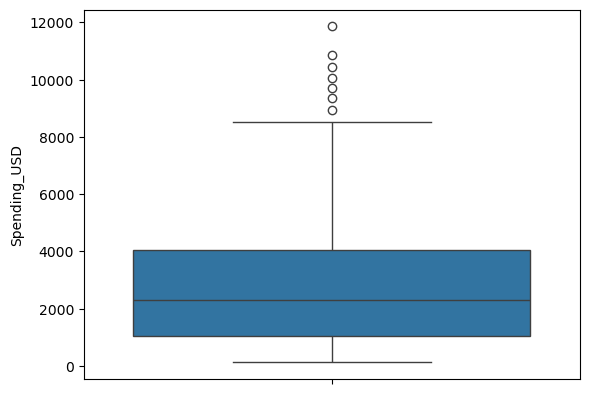


Columns: Life_Expectancy
Min: 70.6		Max: 84.7		Diffrence: 14.100000000000009
:::::::::::::::::::::::::::::::::::::::::::::::::: iris ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: sepal_length
Min: 4.3		Max: 7.9		Diffrence: 3.6000000000000005

Columns: sepal_width
Min: 2.0		Max: 4.4		Diffrence: 2.4000000000000004

Columns: petal_length
Min: 1.0		Max: 6.9		Diffrence: 5.9

Columns: petal_width
Min: 0.1		Max: 2.5		Diffrence: 2.4
:::::::::::::::::::::::::::::::::::::::::::::::::: mpg ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: mpg
Min: 9.0		Max: 46.6		Diffrence: 37.6

Columns: cylinders
Min: 3		Max: 8		Diffrence: 5

Columns: displacement
Min: 68.0		Max: 455.0		Diffrence: 387.0

Columns: horsepower
Min: 46.0		Max: 230.0		Diffrence: 184.0

Columns: weight
Min: 1613		Max: 5140		Diffrence: 3527


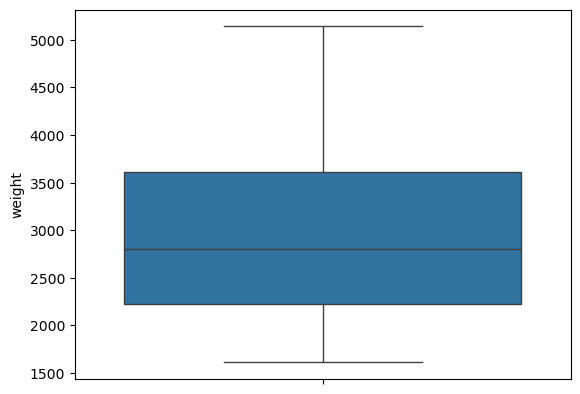


Columns: acceleration
Min: 8.0		Max: 24.8		Diffrence: 16.8

Columns: model_year
Min: 70		Max: 82		Diffrence: 12
:::::::::::::::::::::::::::::::::::::::::::::::::: penguins ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: bill_length_mm
Min: 32.1		Max: 59.6		Diffrence: 27.5

Columns: bill_depth_mm
Min: 13.1		Max: 21.5		Diffrence: 8.4

Columns: flipper_length_mm
Min: 172.0		Max: 231.0		Diffrence: 59.0

Columns: body_mass_g
Min: 2700.0		Max: 6300.0		Diffrence: 3600.0


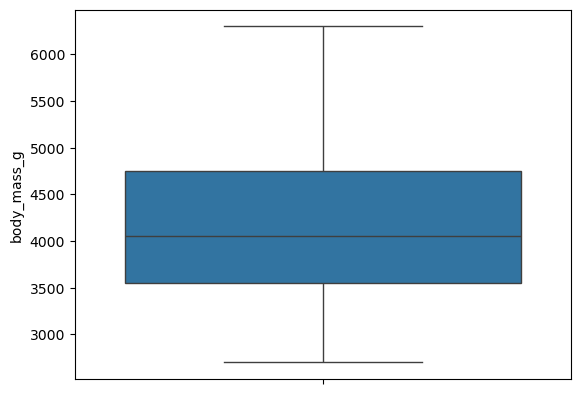

:::::::::::::::::::::::::::::::::::::::::::::::::: planets ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: number
Min: 1		Max: 7		Diffrence: 6

Columns: orbital_period
Min: 0.09070629		Max: 730000.0		Diffrence: 729999.90929371


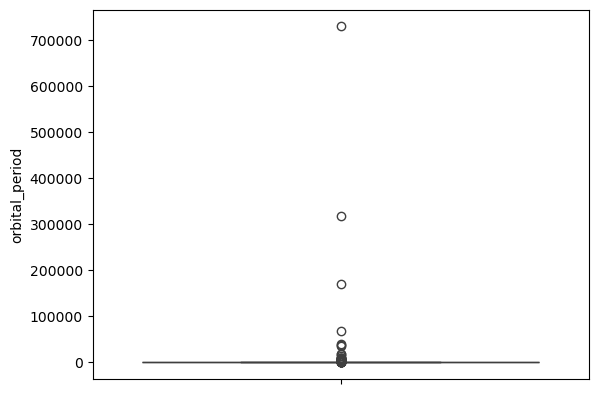


Columns: mass
Min: 0.0036		Max: 25.0		Diffrence: 24.9964

Columns: distance
Min: 1.35		Max: 8500.0		Diffrence: 8498.65


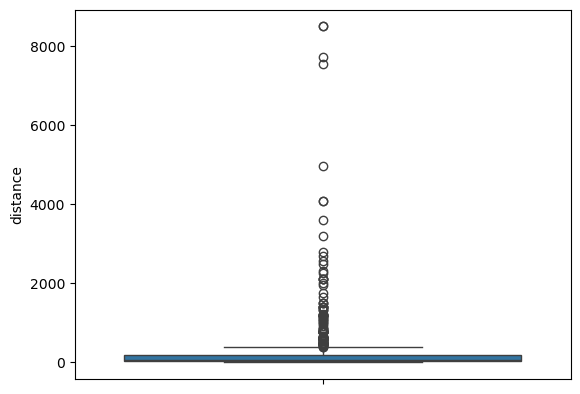


Columns: year
Min: 1989		Max: 2014		Diffrence: 25
:::::::::::::::::::::::::::::::::::::::::::::::::: seaice ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: Extent
Min: 3.34		Max: 16.412		Diffrence: 13.072
:::::::::::::::::::::::::::::::::::::::::::::::::: taxis ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: passengers
Min: 0		Max: 6		Diffrence: 6

Columns: distance
Min: 0.0		Max: 36.7		Diffrence: 36.7

Columns: fare
Min: 1.0		Max: 150.0		Diffrence: 149.0

Columns: tip
Min: 0.0		Max: 33.2		Diffrence: 33.2

Columns: tolls
Min: 0.0		Max: 24.02		Diffrence: 24.02

Columns: total
Min: 1.3		Max: 174.82		Diffrence: 173.51999999999998
:::::::::::::::::::::::::::::::::::::::::::::::::: tips ::::::::::::::::::::::::::::::::::::::::::::::::::

Columns: total_bill
Min: 3.07		Max: 50.81		Diffrence: 47.74

Columns: tip
Min: 1.0		Max: 10.0		Diffrence: 9.0

Columns: size
Min: 1		Max: 6		Diffrence: 5
:::::::::::::::::::::::::::::::::::::::::::::::::: titanic :::::::::::::::::

In [12]:
for data in datasets:
    print(":"*50, data, ":"*50)
    df = sns.load_dataset(data)
    columns = list(df.columns)
    for col in columns:
        if df[col].dtype == 'int64' or df[col].dtype == 'float64':
            print(f"\nColumns: {col}\nMin: {df[col].min()}\t\tMax: {df[col].max()}\t\tDiffrence: {(df[col].max()) - (df[col].min())}")
            if (df[col].max()) - (df[col].min()) > 700:
                sns.boxplot(df[col])
                plt.show()
        

<hr style="height:2.5px;">

# Feature Transformation
    1. Definition
    
        Feature transformation is the process of modifying the mathematical representation of variables in a dataset
        in order to improve the performance of statistical analysis or machine learning models.
                
        Unlike feature scaling, which only changes the scale of data, feature transformation changes the shape or 
        distribution of the feature values.
    
    Mathematically, a transformation can be defined as:
        X′ = f(X)
    
    Where:
        X = original feature
        f(⋅) = transformation function
        X′ = transformed feature
    
    The purpose of transformation is to:
        reduce skewness
        stabilize variance
        improve linear relationships
        make data closer to normal distribution
        enhance model performance

---
# 2. Why Feature Transformation Is Needed
    Many machine learning algorithms assume certain properties of data.
    
Examples:
        Linear regression assumes a linear relationship between variables.
        
        Y = β0 + β1X + ϵ
        If the relationship between X and 𝑌 is nonlinear, the model performs poorly.

        Transformation modifies the variable so that the relationship becomes more linear.

        Y = β0 + β1log(X)

        Similarly, many statistical models perform best when the data distribution is approximately normal.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
data = {
    "Experience": [1,2,3,4,5,6,7,8],
    "Salary": [20000,25000,30000,40000,60000,90000,150000,300000]
}
df = pd.DataFrame(data)
display(df)

,Experience,Salary
0,1,20000
1,2,25000
2,3,30000
3,4,40000
4,5,60000
5,6,90000
6,7,150000
7,8,300000


In [3]:
tips = sns.load_dataset('tips')
tips.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3


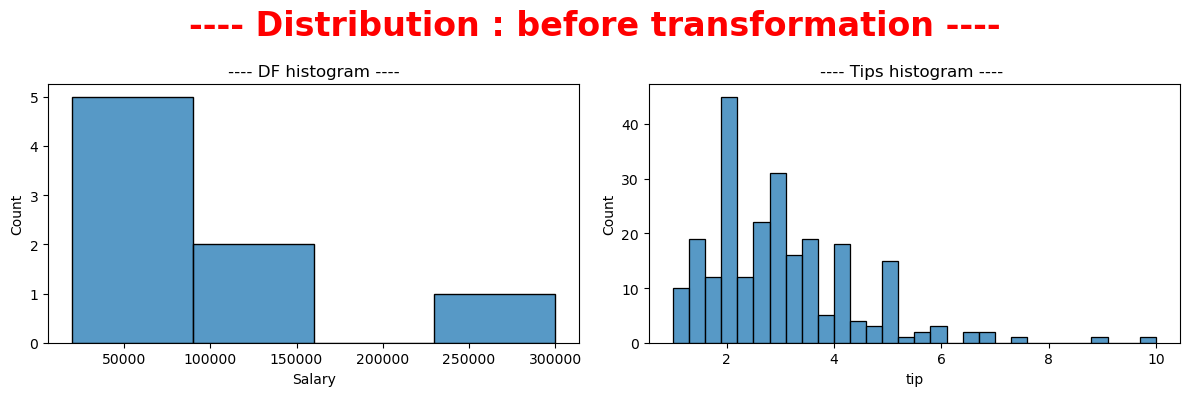

In [19]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['Salary'])
plt.title("---- DF histogram ----")

plt.subplot(1,2,2)
sns.histplot(tips['tip'], bins = 30)
plt.title("---- Tips histogram ---- ")

plt.suptitle("---- Distribution : before transformation ----", size = 24, weight = 'bold', color = 'r')
plt.tight_layout()
plt.show()

---
# Types of Feature Transformation
    Major transformation methods include:
        Log Transformation
        Square Root Transformation
        Reciprocal Transformation
        Power Transformation (Box-Cox)
        Yeo-Johnson Transformation
        Polynomial Transformation
        Quantile Transformation

---
# 1. Log Transformation
    Definition
        Log transformation converts data using the logarithmic function.
        X′ = log(X)
    
        Usually natural logarithm is used.
        X′ = ln(X)

# Mechanism
    The logarithm compresses large values more strongly than small values.
    Example:
        Value	Log Value
        10	    2.30
        100	    4.60
        1000	6.90
    
    Large values shrink significantly.

# Effect
    reduces right skewness
    stabilizes variance
    compresses extreme values

# Use Cases
    Common in:
    income or salary data
    population statistics
    financial growth variables
    exponential growth data

In [18]:
df["Salary_log"] = np.log(df["Salary"])
tips['tip_log'] = np.log(tips['tip'])
display(df.head(2))
display(tips.head(2))

,Experience,Salary,Salary_log
0,1,20000,9.903488
1,2,25000,10.126631


,total_bill,tip,sex,smoker,day,time,size,tip_log
0,16.99,1.01,Female,No,Sun,Dinner,2,0.009950
1,10.34,1.66,Male,No,Sun,Dinner,3,0.506818


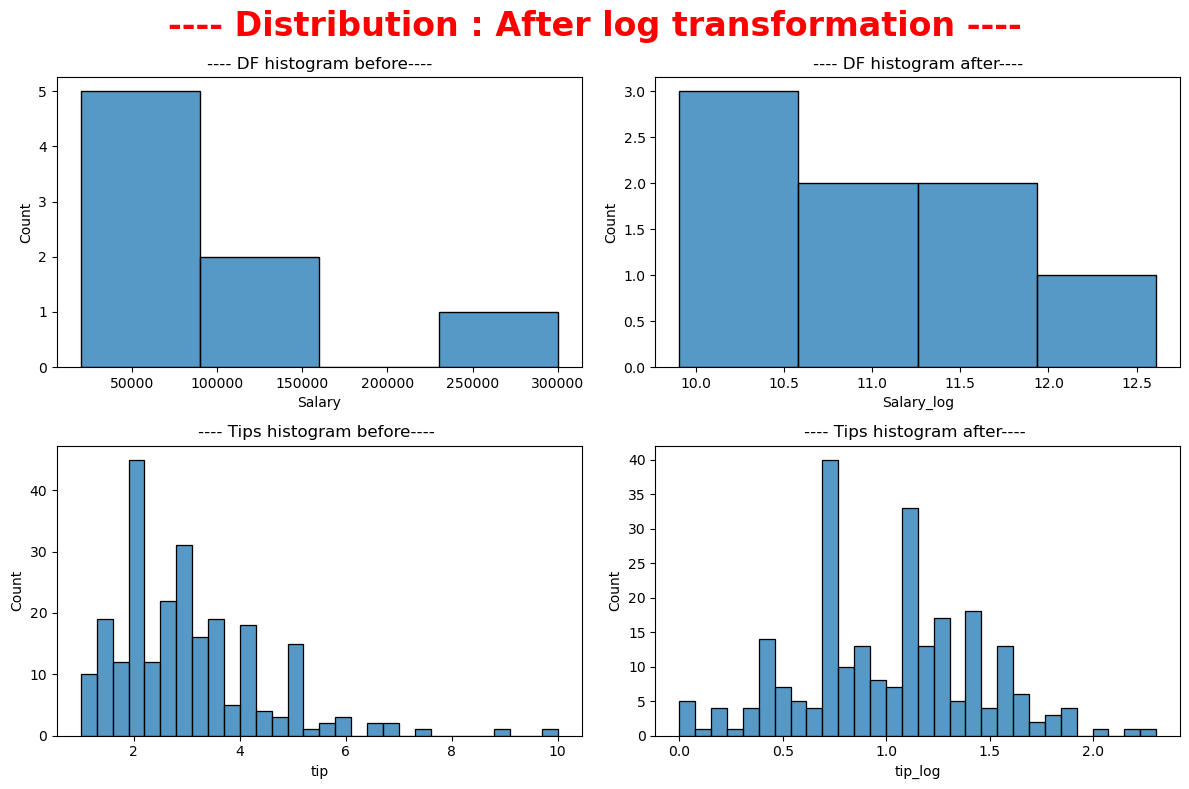

In [24]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.histplot(df['Salary'])
plt.title("---- DF histogram before----")


plt.subplot(2,2,2)
sns.histplot(df['Salary_log'])
plt.title("---- DF histogram after----")

plt.subplot(2,2,3)
sns.histplot(tips['tip'], bins = 30)
plt.title("---- Tips histogram before---- ")

plt.subplot(2,2,4)
sns.histplot(tips['tip_log'], bins = 30)
plt.title("---- Tips histogram after---- ")

plt.suptitle("---- Distribution : After log transformation ----", size = 24, weight = 'bold', color = 'r')
plt.tight_layout()
plt.show()

---
# 2. Square Root Transformation
    Definition
        Square root transformation replaces each value with its square root.
            X′ = sqrt(X)

    Mechanism
        The square root function compresses large values but less aggressively than logarithm.
    
    Example:
        Value	sqrt
        100	    10
        10000	100

    Effect
        reduces moderate skewness
        stabilizes variance

    Use Cases
        Often used for:
                count data
                biological measurements
                moderate skew distributions

In [25]:
df["Salary_sqrt"] = np.sqrt(df["Salary"])
tips['tip_sqrt'] = np.sqrt(tips['tip'])
display(df.head(2))
display(tips.head(2))

,Experience,Salary,Salary_log,Salary_sqrt
0,1,20000,9.903488,141.421356
1,2,25000,10.126631,158.113883


,total_bill,tip,sex,smoker,day,time,size,tip_log,tip_sqrt
0,16.99,1.01,Female,No,Sun,Dinner,2,0.009950,1.004988
1,10.34,1.66,Male,No,Sun,Dinner,3,0.506818,1.288410


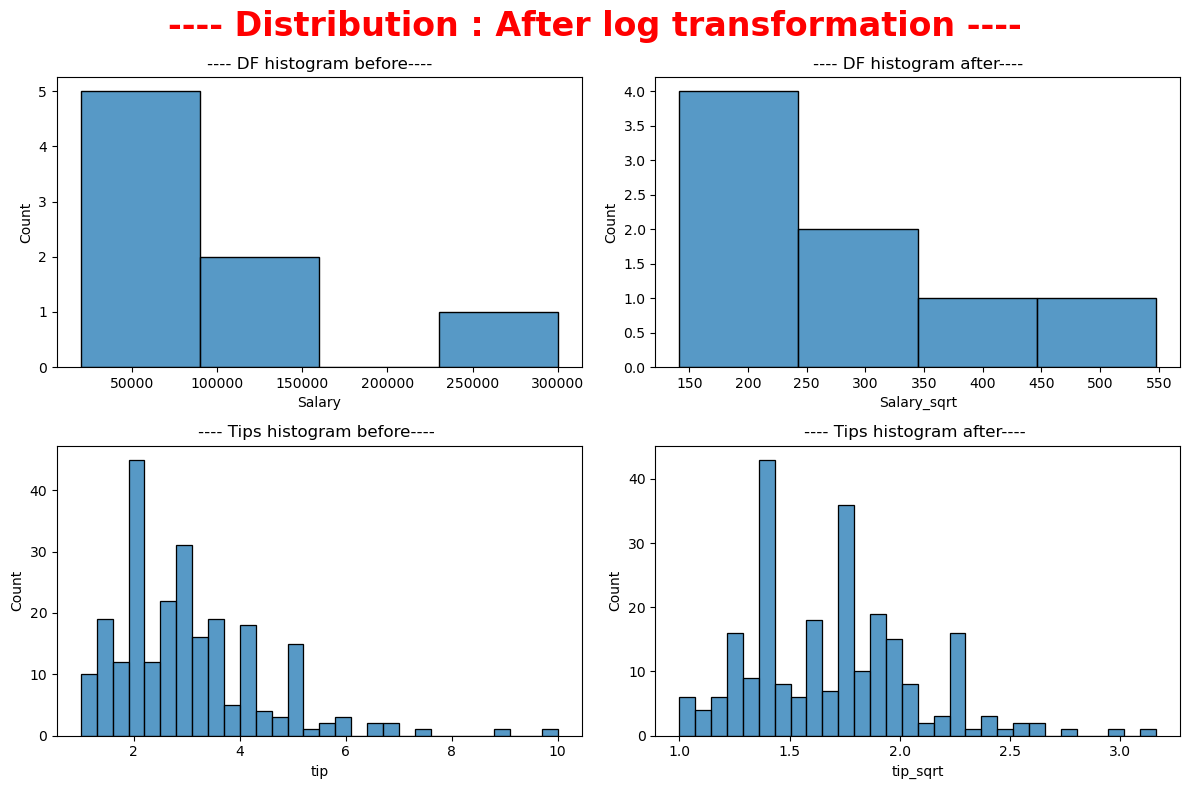

In [26]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.histplot(df['Salary'])
plt.title("---- DF histogram before----")


plt.subplot(2,2,2)
sns.histplot(df['Salary_sqrt'])
plt.title("---- DF histogram after----")

plt.subplot(2,2,3)
sns.histplot(tips['tip'], bins = 30)
plt.title("---- Tips histogram before---- ")

plt.subplot(2,2,4)
sns.histplot(tips['tip_sqrt'], bins = 30)
plt.title("---- Tips histogram after---- ")

plt.suptitle("---- Distribution : After log transformation ----", size = 24, weight = 'bold', color = 'r')
plt.tight_layout()
plt.show()

---
# 3. Reciprocal Transformation
    Definition
        Reciprocal transformation converts values to their inverse.
        𝑋′ = 1 / 𝑋

    Mechanism
        Large values become small and small values become larger.
    
    Example:
        Value	Reciprocal
        2	    0.5
        10	    0.1

    Effect
        strongly reduces large values
        useful for strong right skew

    Use Cases
        Used in:
            time or rate measurements
            chemical concentration analysis
            heavily skewed variables

In [27]:
df["Salary_reciprocal"] = 1 / df["Salary"]
tips['tip_reciprocal'] = 1 / tips['tip']
display(df.head(2))
display(tips.head(2))

,Experience,Salary,Salary_log,Salary_sqrt,Salary_reciprocal
0,1,20000,9.903488,141.421356,0.00005
1,2,25000,10.126631,158.113883,0.00004


,total_bill,tip,sex,smoker,day,time,size,tip_log,tip_sqrt,tip_reciprocal
0,16.99,1.01,Female,No,Sun,Dinner,2,0.009950,1.004988,0.990099
1,10.34,1.66,Male,No,Sun,Dinner,3,0.506818,1.288410,0.602410


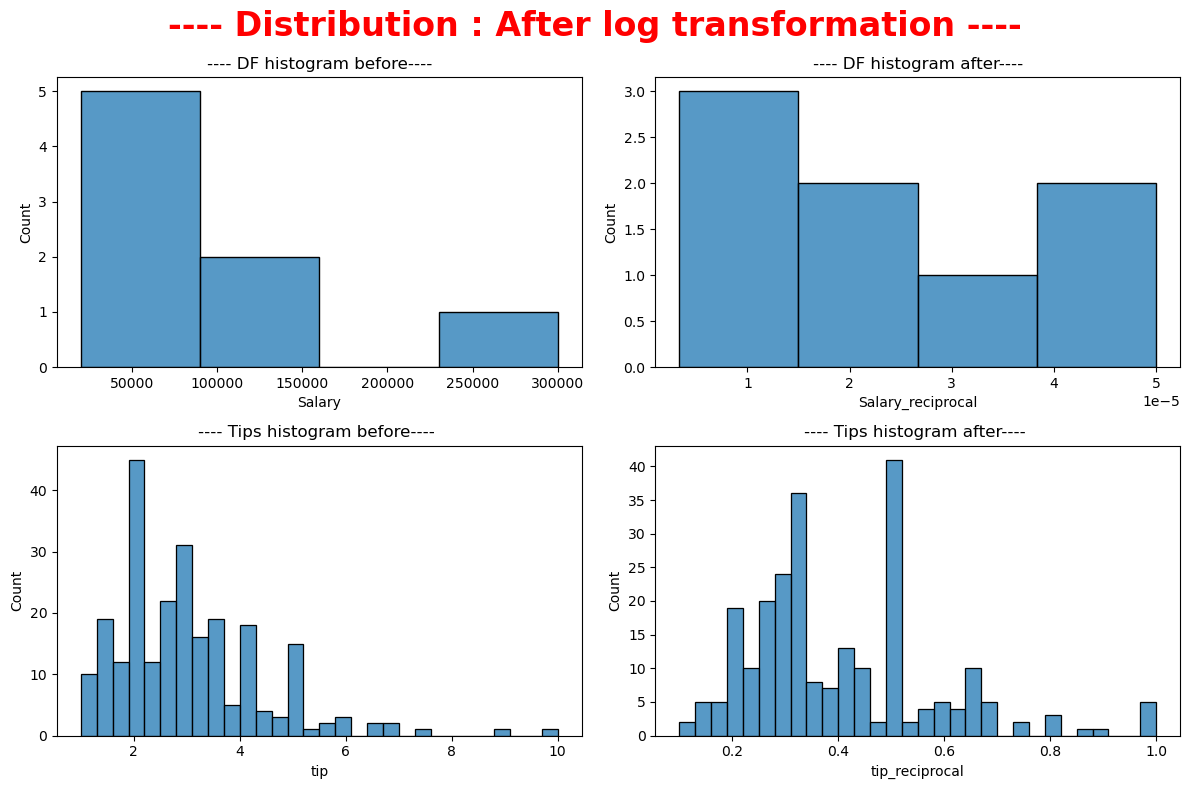

In [28]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.histplot(df['Salary'])
plt.title("---- DF histogram before----")


plt.subplot(2,2,2)
sns.histplot(df['Salary_reciprocal'])
plt.title("---- DF histogram after----")

plt.subplot(2,2,3)
sns.histplot(tips['tip'], bins = 30)
plt.title("---- Tips histogram before---- ")

plt.subplot(2,2,4)
sns.histplot(tips['tip_reciprocal'], bins = 30)
plt.title("---- Tips histogram after---- ")

plt.suptitle("---- Distribution : After log transformation ----", size = 24, weight = 'bold', color = 'r')
plt.tight_layout()
plt.show()

---
# 4. Power Transformation (Box-Cox)
    Definition
        Box-Cox transformation is a family of power transformations used to make data closer to 
        normal distribution.

    Mathematical Formula
    
        For 𝜆 ≠ 0
            𝑋′ = ( (𝑋^𝜆) − 1 ) / 𝜆
        
        For λ=0
            X′ = log(X)


    Mechanism
        The algorithm automatically finds the optimal value of λ that best normalizes the distribution.
    
    Different values of λ produce different transformations:
        λ value	                Transformation
        1	                     no change
        0.5	                     square root
        0	                     log
        -1	                     reciprocal

    Requirements
        Box-Cox requires:
            X>0
        All values must be positive.

    Use Cases
        statistical modeling
        regression models
        normally distributed data requirements

In [38]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='box-cox')
df["Salary_boxcox"] = pt.fit_transform(df[["Salary"]])
tips['tip_boxcox'] = pt.fit_transform(tips[['tip']])
display(df.head(2))
display(tips.head(2))

,Experience,Salary,Salary_log,Salary_sqrt,Salary_reciprocal,Salary_boxcox
0,1,20000,9.903488,141.421356,0.00005,-1.427795
1,2,25000,10.126631,158.113883,0.00004,-1.038830


,total_bill,tip,sex,smoker,day,time,size,tip_log,tip_sqrt,tip_reciprocal,tip_boxcox
0,16.99,1.01,Female,No,Sun,Dinner,2,0.009950,1.004988,0.990099,-2.340991
1,10.34,1.66,Male,No,Sun,Dinner,3,0.506818,1.288410,0.602410,-1.143771


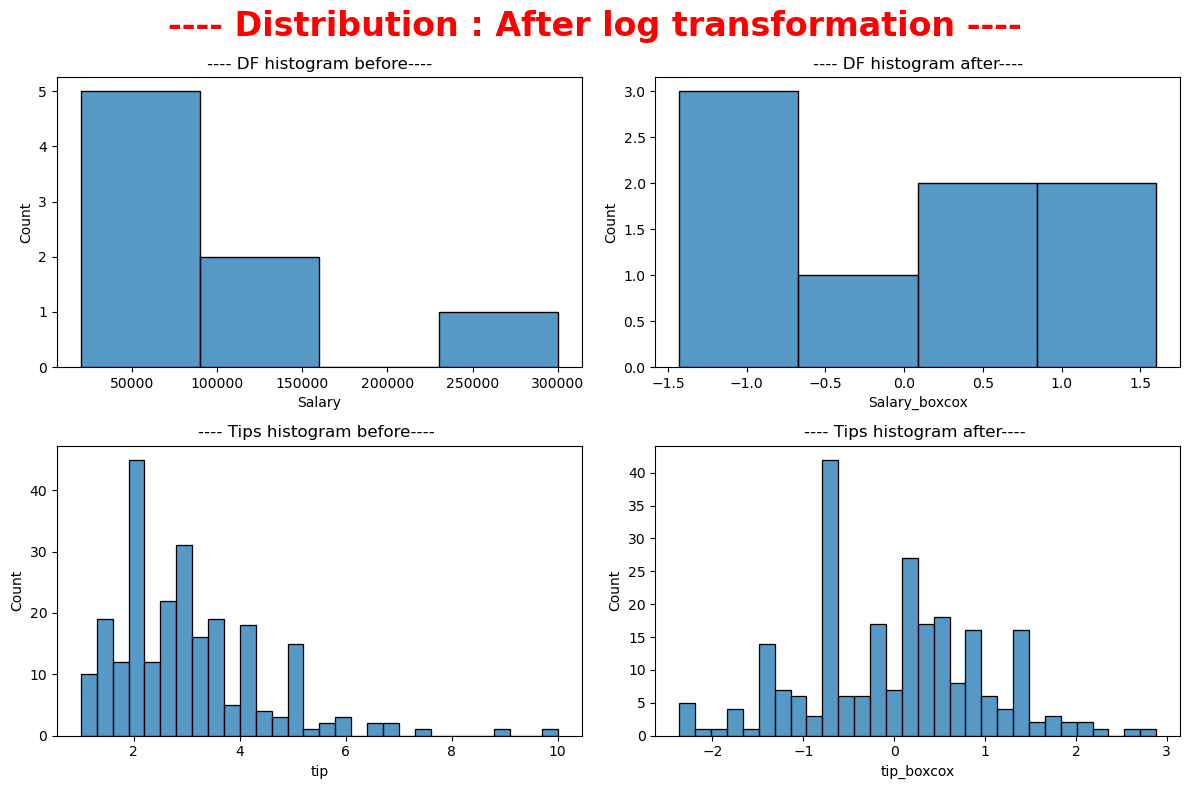

In [39]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.histplot(df['Salary'])
plt.title("---- DF histogram before----")


plt.subplot(2,2,2)
sns.histplot(df['Salary_boxcox'])
plt.title("---- DF histogram after----")

plt.subplot(2,2,3)
sns.histplot(tips['tip'], bins = 30)
plt.title("---- Tips histogram before---- ")

plt.subplot(2,2,4)
sns.histplot(tips['tip_boxcox'], bins = 30)
plt.title("---- Tips histogram after---- ")

plt.suptitle("---- Distribution : After log transformation ----", size = 24, weight = 'bold', color = 'r')
plt.tight_layout()
plt.show()

---
# 5. Yeo-Johnson Transformation
    Definition
        Yeo-Johnson transformation is similar to Box-Cox but works with both positive and negative values.
    
    Mathematical Formulation
        For X≥0
            𝑋′ = ( 𝑋 + 1 ) ^ (𝜆) − 1 / 𝜆
        
        For X<0
            𝑋′ = − ( ((−𝑋 + 1 )^(2 − 𝜆)) − 1 ) / ( 2 − 𝜆 )
    
    Mechanism
        Automatically determines optimal λ to improve normality.

    Use Cases
        datasets with negative values
        skewed distributions
        regression modeling

In [40]:
pt = PowerTransformer(method='yeo-johnson')
df["Salary_yeojohnson"] = pt.fit_transform(df[["Salary"]])
tips['tip_yeojohnson'] = pt.fit_transform(tips[['tip']])
display(df.head(2))
display(tips.head(2))

,Experience,Salary,Salary_log,Salary_sqrt,Salary_reciprocal,Salary_boxcox,Salary_yeojohnson
0,1,20000,9.903488,141.421356,0.00005,-1.427795,-1.427789
1,2,25000,10.126631,158.113883,0.00004,-1.038830,-1.038831


,total_bill,tip,sex,smoker,day,time,size,tip_log,tip_sqrt,tip_reciprocal,tip_boxcox,tip_yeojohnson
0,16.99,1.01,Female,No,Sun,Dinner,2,0.009950,1.004988,0.990099,-2.340991,-2.268391
1,10.34,1.66,Male,No,Sun,Dinner,3,0.506818,1.288410,0.602410,-1.143771,-1.156975


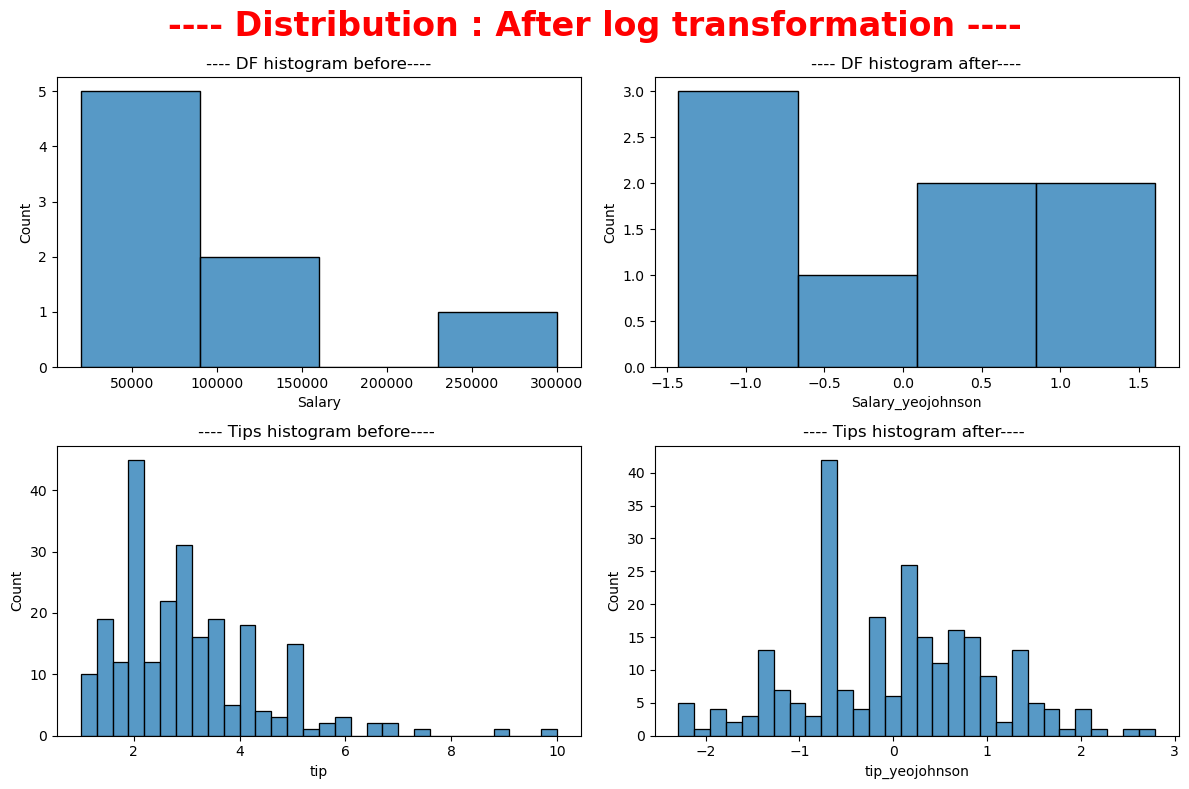

In [41]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.histplot(df['Salary'])
plt.title("---- DF histogram before----")


plt.subplot(2,2,2)
sns.histplot(df['Salary_yeojohnson'])
plt.title("---- DF histogram after----")

plt.subplot(2,2,3)
sns.histplot(tips['tip'], bins = 30)
plt.title("---- Tips histogram before---- ")

plt.subplot(2,2,4)
sns.histplot(tips['tip_yeojohnson'], bins = 30)
plt.title("---- Tips histogram after---- ")

plt.suptitle("---- Distribution : After log transformation ----", size = 24, weight = 'bold', color = 'r')
plt.tight_layout()
plt.show()

---
# 6. Polynomial Transformation
    Definition
        Polynomial transformation creates new features by raising existing features to powers.

    Mathematical Representation
    For feature 𝑋:
        X^2 , X^3 , X^4

    Interaction terms may also be included:
        X1X2

    Mechanism
        Transforms nonlinear relationships into linear ones.
    
    Example:
        Original relationship:
            Y = aX^2 + b

    Linear regression cannot model this directly.
    Polynomial features allow representation.

    Use Cases
        nonlinear regression problems
        curve fitting
        engineering modeling

In [43]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
poly_features = poly.fit_transform(df[["Experience"]])
display(poly_features)

array([[ 1.,  1.,  1.],
       [ 1.,  2.,  4.],
       [ 1.,  3.,  9.],
       [ 1.,  4., 16.],
       [ 1.,  5., 25.],
       [ 1.,  6., 36.],
       [ 1.,  7., 49.],
       [ 1.,  8., 64.]])

---
# 7. Quantile Transformation
    Definition
        Quantile transformation maps data to a uniform or normal distribution based on ranking.

    Mechanism
        Steps:
        Sort the data
        Compute cumulative probability
        Map values to desired distribution

    Mathematical Concept
    Empirical cumulative distribution function:
        F(x)=P(X≤x)
    Each value is mapped to its quantile.

    Use Cases
        highly skewed distributions
        nonparametric transformations
        robust preprocessing

In [44]:
from sklearn.preprocessing import QuantileTransformer
qt = QuantileTransformer(output_distribution='normal')
df["Salary_quantile"] = qt.fit_transform(df[["Salary"]])
tips['tip_quantile'] = qt.fit_transform(tips[['tip']])
display(df.head(2))
display(tips.head(2))

E:\Anaconda\Lib\site-packages\sklearn\preprocessing\_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (8). n_quantiles is set to n_samples.
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\preprocessing\_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (244). n_quantiles is set to n_samples.
  warnings.warn(


,Experience,Salary,Salary_log,Salary_sqrt,Salary_reciprocal,Salary_boxcox,Salary_yeojohnson,Salary_quantile
0,1,20000,9.903488,141.421356,0.00005,-1.427795,-1.427789,-5.199338
1,2,25000,10.126631,158.113883,0.00004,-1.038830,-1.038831,-1.067571


,total_bill,tip,sex,smoker,day,time,size,tip_log,tip_sqrt,tip_reciprocal,tip_boxcox,tip_yeojohnson,tip_quantile
0,16.99,1.01,Female,No,Sun,Dinner,2,0.009950,1.004988,0.990099,-2.340991,-2.268391,-2.133036
1,10.34,1.66,Male,No,Sun,Dinner,3,0.506818,1.288410,0.602410,-1.143771,-1.156975,-1.118451


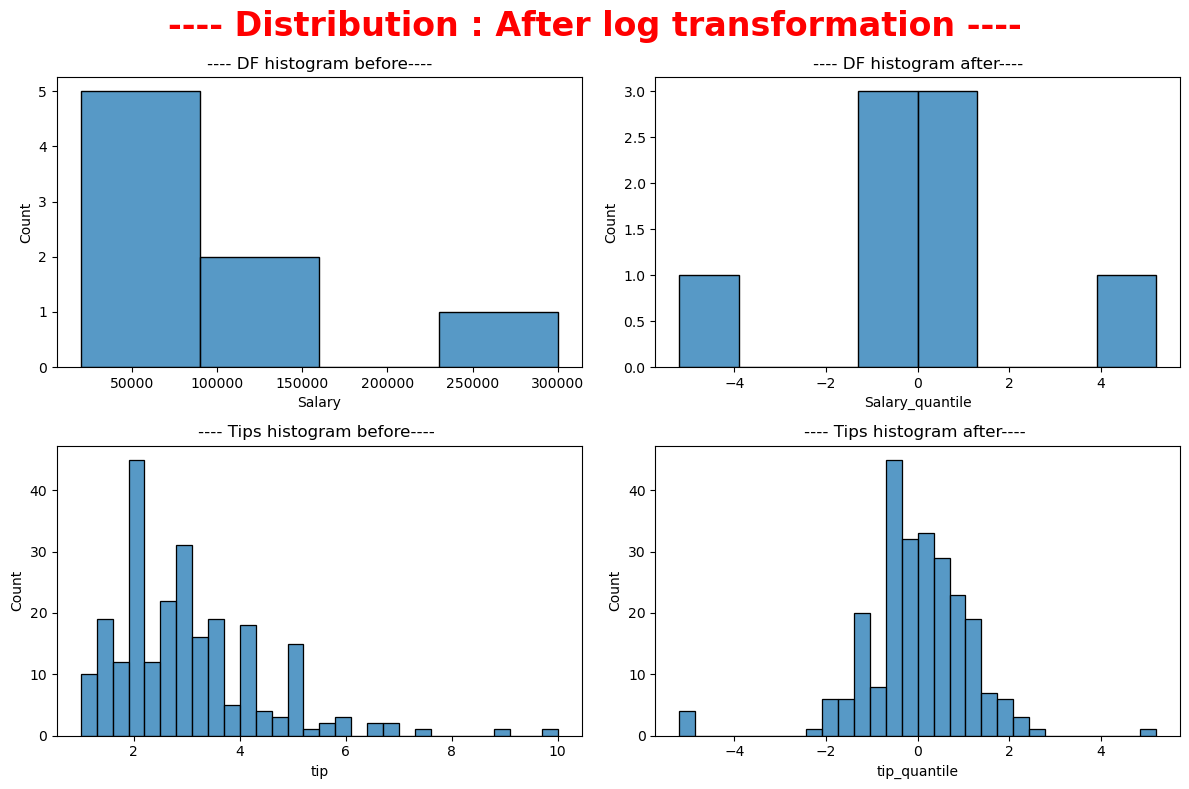

In [45]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.histplot(df['Salary'])
plt.title("---- DF histogram before----")


plt.subplot(2,2,2)
sns.histplot(df['Salary_quantile'])
plt.title("---- DF histogram after----")

plt.subplot(2,2,3)
sns.histplot(tips['tip'], bins = 30)
plt.title("---- Tips histogram before---- ")

plt.subplot(2,2,4)
sns.histplot(tips['tip_quantile'], bins = 30)
plt.title("---- Tips histogram after---- ")

plt.suptitle("---- Distribution : After log transformation ----", size = 24, weight = 'bold', color = 'r')
plt.tight_layout()
plt.show()

----
----
# Recommended Workflow
    Examine distribution of variables
    Identify skewness or nonlinear relationships
    Choose appropriate transformation
    Validate distribution improvement
    apply model training
----
----

<hr style="height:2.5px;">

# 1. Data Reduction
    Definition
        Data Reduction is the process of reducing the size of a dataset while preserving the important information contained 
        within it so that analytical results obtained from the reduced dataset are similar to those obtained from the original 
        dataset.

    If the original dataset is represented as:
        D={ x1 , x2 , x3 , ... , xn }

    Data reduction produces a smaller dataset:
        𝐷′ = { 𝑥′1, 𝑥′2, 𝑥′3 , ... , 𝑥′𝑚 }

    where
        m<n

    and the goal is
        Information(D′) ≈ Information(D)

    This means the reduced dataset should still represent the patterns and relationships of the original data.

---
    Why Data Reduction is Required
        Large datasets create several problems:
        High computational cost
        Increased storage requirements
        Slow machine learning training
        Curse of dimensionality
        Model overfitting

    Data reduction techniques attempt to solve these problems by compressing the data representation.
---

    Major Types of Data Reduction
    
        Data reduction methods are mainly divided into the following categories:
            Dimensionality Reduction
            Numerosity Reduction
            Sampling
            Data Compression
            Feature Selection
            Data Cube Aggregation
            Histogram Based Reduction
            Clustering Based Reduction
    
    Each technique reduces data differently.

---
# Example Dataset for Demonstration
    We will use the following dataset.

In [6]:
import pandas as pd
import numpy as np
data = {
    "Age":[22,25,28,30,35,40,42,45,48,50],
    "Experience":[1,2,4,5,7,10,12,14,16,18],
    "Salary":[20000,25000,30000,40000,50000,80000,90000,110000,130000,150000]
}
df = pd.DataFrame(data)
display(df)

TypeError: 'DataFrame' object is not callable

---
# 1. Dimensionality Reduction
    Definition
        Dimensionality reduction is the process of reducing the number of variables (features) in a dataset while preserving 
        as much information as possible.

    If the dataset has 𝑝 features:
        X = (x1 , x2 , x3 ,..., xp)

    Dimensionality reduction produces:
        Z = (z1 , z2 ,..., zk )

    Where
        k<p

The new variables are combinations of original features.

## Method 1: Principal Component Analysis (PCA)
    Definition
        Principal Component Analysis transforms correlated variables into a smaller number of uncorrelated variables
        called principal components.
    Mechanism of PCA

    Step 1: Standardize the data
    
    Standardization converts data to zero mean and unit variance.
        Z = (X − μ) / σ
    Where
        X = original value
        μ = mean
        σ = standard deviation

    Step 2: Compute Covariance Matrix
        The covariance matrix measures relationships between variables.
            𝐶𝑜𝑣(𝑋 , 𝑌) = ( ∑(𝑋𝑖 − (𝑋^ˉ)) ((𝑌𝑖) − (𝑌^ˉ)) )/ 𝑛−1

        Covariance matrix form:
            C = (1/n−1)( (Z^T) Z )

    Step 3: Compute Eigenvalues and Eigenvectors
        Cv=λv
    Where
        𝑣 = eigenvector
        𝜆 = eigenvalue
    Eigenvectors represent directions of maximum variance.

    Step 4: Select top components
        Components with highest eigenvalues are chosen.

    Step 5: Transform data
        Y=XW

    Where 𝑊 contains the selected eigenvectors.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X = df[["Age","Experience","Salary"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)
display(df)
dispay(X_reduced)

TypeError: 'DataFrame' object is not callable